# NB08 — Real Persistence Forecast Comparison

Tests the FCR-D sequential auction pipeline with **real persistence forecasts**
rather than synthetic Gaussian random walk noise.

Two persistence baselines:
- **Daily persistence**: forecast for day D = actual values from day D−1 (same hour)
- **Weekly persistence**: forecast for day D = actual values from day D−7 (same hour)

Results are overlaid on the NB07 revenue-vs-α noise sensitivity curves
to calibrate where real-world forecasting difficulty sits relative to the
synthetic noise model.

## 1 — Imports and configuration

In [81]:
import warnings
from pathlib import Path
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pyomo.environ import (
    ConcreteModel, Set, Param, Var, Objective, Constraint,
    NonNegativeReals, Reals, Binary, minimize, value, SolverFactory,
)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

DATA_DIR  = Path('../data/data_out')
DATA_FILE = DATA_DIR / 'combined_2025_with_frequency.csv'

N_ECS = 10; B_MAX_EC = 100.0; S_MAX_EC = 200.0
ETA_MEAN = 0.95; ETA_SIGMA = 0.0; T_SUSTAIN = 0.5
P_MIN = 100.0; SOC_INIT_FRAC = 0.5; SOLVER = 'appsi_highs'
P_B_CHANCE = 0.6; SCALE_MU = 1.0; SCALE_SIGMA = 1.0

EARLY_PV_NOISE_STD = 0.0; EARLY_D_NOISE_STD = 0.0; EARLY_ACT_NOISE_STD = 0.0
P_BAR_AGG = N_ECS * B_MAX_EC; S_AGG = N_ECS * S_MAX_EC

TEST_DATE = datetime.date(2025, 5, 10)


plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#FAFAFA',
    'axes.edgecolor':    '#CCCCCC',
    'axes.grid':         True,
    'grid.color':        '#E5E5E5',
    'grid.linewidth':    0.6,
    'font.family':       'serif',
    'font.serif':        ['DejaVu Serif', 'Liberation Serif', 'Times New Roman', 'serif'],
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'figure.dpi':        130,
    'legend.framealpha':  0.85,
    'legend.edgecolor':  '#CCCCCC',
})

# Alpha values calibrated so average noise across 24 delivery hours
# equals the target percentage of the variable's mean level.
# These are computed in Section 4 after empirical sigmas are known.
TARGET_NOISE_PCTS = [0, 5, 10, 20, 40]   # target avg noise as % of mean level
RANDOM_SEED = 42

print(f'Portfolio: {P_BAR_AGG:.0f} kW / {S_AGG:.0f} kWh')
print(f'Test date: {TEST_DATE}')
print(f'Target noise levels: {TARGET_NOISE_PCTS}%')


Portfolio: 1000 kW / 2000 kWh
Test date: 2025-05-10
Target noise levels: [0, 5, 10, 20, 40]%


## 2 — Synthetic EC portfolio

In [52]:
rng = np.random.default_rng(42)
EC_LIST = []
for i in range(N_ECS):
    base = 'b' if rng.random() < P_B_CHANCE else 's'
    scale = -1.0
    while scale <= 0:
        scale = float(rng.normal(SCALE_MU, SCALE_SIGMA))
    eta_e = ETA_MEAN
    EC_LIST.append({'id': f'ec{i:02d}', 'base': base, 'scale': scale,
                    'b_max': B_MAX_EC, 's_max': S_MAX_EC, 'eta': eta_e})
EC_IDS = [ec['id'] for ec in EC_LIST]
EC_BY_ID = {ec['id']: ec for ec in EC_LIST}
n_b = sum(1 for e in EC_LIST if e['base'] == 'b')
print(f'{N_ECS} ECs: {n_b} b-type, {N_ECS-n_b} s-type')


10 ECs: 4 b-type, 6 s-type


## 3 — Load data

In [53]:
df_raw = pd.read_csv(DATA_FILE, parse_dates=['hour_utc'])
df_raw['spot_dkk']       = df_raw['spot_exkl_vat_ore_kwh'] / 100.0
df_raw['buy_price_dkk']  = df_raw['buy_price_inkl_vat_ore_kwh'] / 100.0
df_raw['sell_price_dkk'] = df_raw['sell_price_inkl_vat_ore_kwh'] / 100.0
df_raw['buy_markup_dkk'] = df_raw['buy_price_dkk'] - df_raw['spot_dkk']
df_raw['sell_markup_dkk']= df_raw['sell_price_dkk'] - df_raw['spot_dkk']
df_raw['fcrd_up_early_dkk'] = df_raw['price_ore_kwh_fcr_d_upp__d_1_early'].fillna(0).clip(lower=0) / 100.0
df_raw['fcrd_up_late_dkk']  = df_raw['price_ore_kwh_fcr_d_upp__d_1_late' ].fillna(0).clip(lower=0) / 100.0
df_raw['fcrd_dn_early_dkk'] = df_raw['price_ore_kwh_fcr_d_ned__d_1_early'].fillna(0).clip(lower=0) / 100.0
df_raw['fcrd_dn_late_dkk']  = df_raw['price_ore_kwh_fcr_d_ned__d_1_late' ].fillna(0).clip(lower=0) / 100.0
df_raw['y_act_up'] = df_raw['y_act_fcrd_up'].fillna(0).clip(0, 1)
df_raw['y_act_dn'] = df_raw['y_act_fcrd_down'].fillna(0).clip(0, 1)
df = df_raw[df_raw['data_quality_flag'] == 0].copy()
df['date'] = df['hour_utc'].dt.date
df_b = df[df['ec_id'] == 'b'].set_index('hour_utc').sort_index()
df_s = df[df['ec_id'] == 's'].set_index('hour_utc').sort_index()
all_dates = sorted(set(df_b.index.date))
print(f'EC b: {len(df_b)} hours  |  EC s: {len(df_s)} hours')
print(f'Test date {TEST_DATE} available: {TEST_DATE in all_dates}')


EC b: 8745 hours  |  EC s: 8745 hours
Test date 2025-05-10 available: True


## 4 — Empirical σ̂ and alpha calibration

Compute empirical σ̂ for each variable, then calibrate alpha values so that
the **average noise standard deviation across the 24 delivery hours** equals
a target percentage of the variable's mean level.

For a random walk with per-step σ, the std at position k is √k · σ.
For the early auction (48h horizon, extract [24:48]):
  avg_std = mean(√(24+h) for h=0..23) · σ = mean_sqrt_early · α · σ̂

Setting avg_std = target_pct × mean_level:
  α = (target_pct × mean_level) / (mean_sqrt_early · σ̂)


In [54]:
def compute_empirical_sigma(series):
    s = series.copy(); s.index = pd.to_datetime(s.index)
    diff = (s - s.shift(24)).dropna()
    return pd.DataFrame({'diff': diff.values, 'hour': diff.index.hour}).groupby('hour')['diff'].std().mean()

empirical_sigmas = {
    'load_b':         compute_empirical_sigma(df_b['consumption']),
    'load_s':         compute_empirical_sigma(df_s['consumption']),
    'pv_b':           compute_empirical_sigma(df_b['pv_production_kwh']),
    'pv_s':           compute_empirical_sigma(df_s['pv_production_kwh']),
    'spot':           compute_empirical_sigma(df_b['spot_dkk']),
    'fcrd_up_early':  compute_empirical_sigma(df_b['fcrd_up_early_dkk']),
    'fcrd_dn_early':  compute_empirical_sigma(df_b['fcrd_dn_early_dkk']),
    'fcrd_up_late':   compute_empirical_sigma(df_b['fcrd_up_late_dkk']),
    'fcrd_dn_late':   compute_empirical_sigma(df_b['fcrd_dn_late_dkk']),
}

# Mean levels of each variable (for nRMSE normalization and alpha calibration)
mean_levels = {
    'load_b':        df_b['consumption'].mean(),
    'load_s':        df_s['consumption'].mean(),
    'pv_b':          df_b['pv_production_kwh'].mean(),
    'pv_s':          df_s['pv_production_kwh'].mean(),
    'spot':          df_b['spot_dkk'].mean(),
    'fcrd_up_early': df_b['fcrd_up_early_dkk'].mean(),
    'fcrd_dn_early': df_b['fcrd_dn_early_dkk'].mean(),
    'fcrd_up_late':  df_b['fcrd_up_late_dkk'].mean(),
    'fcrd_dn_late':  df_b['fcrd_dn_late_dkk'].mean(),
}

# Single PV sigma_hat: all buildings share the same weather forecast error.
# Use average of b and s base curves.
empirical_sigmas['pv'] = (empirical_sigmas['pv_b'] + empirical_sigmas['pv_s']) / 2.0
mean_levels['pv']      = (mean_levels['pv_b']      + mean_levels['pv_s'])      / 2.0

# Random walk accumulation factors
MEAN_SQRT_EARLY = np.mean([np.sqrt(24 + h) for h in range(24)])  # ~5.93
MEAN_SQRT_LATE  = np.mean([np.sqrt(6  + h) for h in range(24)])  # ~4.10

print('Empirical σ̂ and mean levels:')
print('=' * 75)
print(f'{"Variable":<20s} {"σ̂":>12s} {"Mean level":>12s} {"Unit":>10s}')
print('-' * 75)
for k in empirical_sigmas:
    unit = 'kWh' if 'load' in k or 'pv' in k else 'DKK/kWh'
    print(f'{k:<20s} {empirical_sigmas[k]:>12.6f} {mean_levels[k]:>12.6f} {unit:>10s}')
print(f'\nRandom walk accumulation: early mean √k = {MEAN_SQRT_EARLY:.2f}, late = {MEAN_SQRT_LATE:.2f}')


Empirical σ̂ and mean levels:
Variable                       σ̂   Mean level       Unit
---------------------------------------------------------------------------
load_b                   2.294975    13.271536        kWh
load_s                   2.320554    12.097730        kWh
pv_b                     2.584634     3.953083        kWh
pv_s                     3.857522     5.474343        kWh
spot                     0.335705     0.615862    DKK/kWh
fcrd_up_early            0.063146     0.043816    DKK/kWh
fcrd_dn_early            0.040484     0.036654    DKK/kWh
fcrd_up_late             0.140898     0.047574    DKK/kWh
fcrd_dn_late             0.706017     0.060651    DKK/kWh
pv                       3.221078     4.713713        kWh

Random walk accumulation: early mean √k = 5.93, late = 4.09


## 5 — Model builders (from NB06)

In [55]:
def build_early(day, fcrd=True):
    #Early-auction FCR-D MILP (Program 1).  fcrd=False → base battery only.
    m = ConcreteModel()
    T = list(range(1, 25))
    m.E = Set(initialize=EC_IDS)
    m.T = Set(initialize=T)

    # ── Parameters ──────────────────────────────────────────────────────
    m.D  = Param(m.E, m.T, initialize={(e,t): day['D' ][e][t-1] for e in EC_IDS for t in T})
    m.PV = Param(m.E, m.T, initialize={(e,t): day['PV'][e][t-1] for e in EC_IDS for t in T})
    m.b_max = Param(m.E, initialize={e: EC_BY_ID[e]['b_max'] for e in EC_IDS})
    m.s_max = Param(m.E, initialize={e: EC_BY_ID[e]['s_max'] for e in EC_IDS})
    m.eta   = Param(m.E, initialize={e: EC_BY_ID[e]['eta'  ] for e in EC_IDS})
    m.buy   = Param(m.T, initialize={t: day['buy_price' ][t-1] for t in T})
    m.sell  = Param(m.T, initialize={t: day['sell_price'][t-1] for t in T})
    if fcrd:
        m.lam_up   = Param(m.T, initialize={t: day['fcrd_up_price'][t-1] for t in T})
        m.lam_dn   = Param(m.T, initialize={t: day['fcrd_dn_price'][t-1] for t in T})
        m.y_act_up = Param(m.T, initialize={t: day['y_act_up'     ][t-1] for t in T})
        m.y_act_dn = Param(m.T, initialize={t: day['y_act_dn'     ][t-1] for t in T})

    # ── Decision variables ───────────────────────────────────────────────
    m.p_im  = Var(m.E, m.T, domain=NonNegativeReals)
    m.p_ex  = Var(m.E, m.T, domain=NonNegativeReals)
    m.p_net = Var(m.E, m.T, domain=Reals)
    m.b_ch  = Var(m.E, m.T, domain=NonNegativeReals)
    m.b_dis = Var(m.E, m.T, domain=NonNegativeReals)
    m.soc   = Var(m.E, m.T, domain=NonNegativeReals)
    if fcrd:
        m.p_res_up = Var(m.E, m.T, domain=NonNegativeReals)
        m.p_res_dn = Var(m.E, m.T, domain=NonNegativeReals)
        m.p_act_up = Var(m.E, m.T, domain=NonNegativeReals)
        m.p_act_dn = Var(m.E, m.T, domain=NonNegativeReals)
        m.z_up = Var(m.T, domain=Binary)
        m.z_dn = Var(m.T, domain=Binary)

    # ── (E-obj) Objective ────────────────────────────────────────────────
    if fcrd:
        m.obj = Objective(sense=minimize, expr=sum(
              m.buy[t]  * (sum(m.p_im[e,t] for e in m.E) - sum(m.p_act_dn[e,t] for e in m.E))
            - m.sell[t] * (sum(m.p_ex[e,t] for e in m.E) - sum(m.p_act_up[e,t] for e in m.E))
            - m.lam_up[t] * sum(m.p_res_up[e,t] for e in m.E)
            - m.lam_dn[t] * sum(m.p_res_dn[e,t] for e in m.E)
            for t in m.T))
    else:
        m.obj = Objective(sense=minimize, expr=sum(
            m.buy[t]*m.p_im[e,t] - m.sell[t]*m.p_ex[e,t]
            for e in m.E for t in m.T))

    # ── (E-1) Net power balance ──────────────────────────────────────────
    m.c_m1b = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_net[e,t] - m.p_im[e,t] + m.p_ex[e,t] == 0)

    # ── (E-4) Battery power balance ──────────────────────────────────────
    def _c2i(m,e,t):
        rhs = m.p_net[e,t] + m.PV[e,t] - m.D[e,t] - m.b_ch[e,t] + m.b_dis[e,t]
        if fcrd: rhs = rhs - m.p_act_dn[e,t] + m.p_act_up[e,t]
        return rhs == 0
    m.c_c2i = Constraint(m.E, m.T, rule=_c2i)

    if fcrd:
        # ── (E-5) Activation linkers ─────────────────────────────────────
        m.c_c3b_up = Constraint(m.E, m.T,
            rule=lambda m,e,t: m.p_act_up[e,t] == m.y_act_up[t] * m.p_res_up[e,t])
        m.c_c3b_dn = Constraint(m.E, m.T,
            rule=lambda m,e,t: m.p_act_dn[e,t] == m.y_act_dn[t] * m.p_res_dn[e,t])

    # ── (E-6a) SOC dynamics t ≥ 2 ───────────────────────────────────────
    def _m2j(m,e,t):
        if t == 1: return Constraint.Skip
        gain  = m.b_ch[e,t]  + (m.p_act_dn[e,t] if fcrd else 0)
        drain = m.b_dis[e,t] + (m.p_act_up[e,t] if fcrd else 0)
        return m.soc[e,t] == m.soc[e,t-1] + m.eta[e]*gain - (1/m.eta[e])*drain
    m.c_m2j = Constraint(m.E, m.T, rule=_m2j)

    # ── (E-6b) SOC at t=1 ───────────────────────────────────────────────
    def _m2k(m,e):
        gain  = m.b_ch[e,1]  + (m.p_act_dn[e,1] if fcrd else 0)
        drain = m.b_dis[e,1] + (m.p_act_up[e,1] if fcrd else 0)
        return m.soc[e,1] == SOC_INIT_FRAC*m.s_max[e] + m.eta[e]*gain - (1/m.eta[e])*drain
    m.c_m2k = Constraint(m.E, rule=_m2k)

    # ── (E-6c) Terminal SOC ──────────────────────────────────────────────
    m.c_c1l = Constraint(m.E,
        rule=lambda m,e: m.soc[e,24] == SOC_INIT_FRAC*m.s_max[e])

    if fcrd:
        # ── (E-7) SOC sustain ─────────────────────────────────────────────
        m.c_m13_up = Constraint(m.E, m.T,
            rule=lambda m,e,t: m.soc[e,t] >= (T_SUSTAIN/m.eta[e])*m.p_res_up[e,t])
        m.c_m13_dn = Constraint(m.E, m.T,
            rule=lambda m,e,t: (m.s_max[e]-m.soc[e,t]) >= T_SUSTAIN*m.eta[e]*m.p_res_dn[e,t])
        # ── (E-8) Power limits ────────────────────────────────────────────
        m.c_c1m = Constraint(m.E, m.T,
            rule=lambda m,e,t: m.b_ch[e,t]  + m.p_res_dn[e,t] <= m.b_max[e])
        m.c_c3c = Constraint(m.E, m.T,
            rule=lambda m,e,t: m.b_dis[e,t] + m.p_res_up[e,t] <= m.b_max[e])
    else:
        m.c_bch  = Constraint(m.E, m.T, rule=lambda m,e,t: m.b_ch[e,t]  <= m.b_max[e])
        m.c_bdis = Constraint(m.E, m.T, rule=lambda m,e,t: m.b_dis[e,t] <= m.b_max[e])

    # ── SOC ≤ S̄ (always) ────────────────────────────────────────────────
    m.c_soc_max = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.soc[e,t] <= m.s_max[e])

    if fcrd:
        # ── (E-9) SOC headroom ────────────────────────────────────────────
        m.c_c3d_up = Constraint(m.E, m.T,
            rule=lambda m,e,t: m.soc[e,t] >= m.p_res_up[e,t])
        m.c_c3d_dn = Constraint(m.E, m.T,
            rule=lambda m,e,t: (m.s_max[e]-m.soc[e,t]) >= m.p_res_dn[e,t])
        # ── (E-10) Min-bid disjunctions (portfolio level) ─────────────────
        m.c_m1_up_lo = Constraint(m.T,
            rule=lambda m,t: P_MIN*m.z_up[t] <= sum(m.p_res_up[e,t] for e in m.E))
        m.c_m1_up_hi = Constraint(m.T,
            rule=lambda m,t: sum(m.p_res_up[e,t] for e in m.E) <= P_BAR_AGG*m.z_up[t])
        m.c_m1_dn_lo = Constraint(m.T,
            rule=lambda m,t: P_MIN*m.z_dn[t] <= sum(m.p_res_dn[e,t] for e in m.E))
        m.c_m1_dn_hi = Constraint(m.T,
            rule=lambda m,t: sum(m.p_res_dn[e,t] for e in m.E) <= P_BAR_AGG*m.z_dn[t])
    return m


def solve_model(m):
    return SolverFactory(SOLVER).solve(m, tee=False)

In [56]:
def extract_early_accepted(m_early):
    #Pull accepted (offered) reservation quantities from a solved early model.
    acc_up, acc_dn = {}, {}
    for e in EC_IDS:
        for t in range(1, 25):
            acc_up[(e,t)] = max(0.0, value(m_early.p_res_up[e,t]))
            acc_dn[(e,t)] = max(0.0, value(m_early.p_res_dn[e,t]))
    return acc_up, acc_dn


def build_late(day_late, early_acc_up, early_acc_dn,
               early_clearing_up, early_clearing_dn):
    m = ConcreteModel()
    T = list(range(1, 25))
    m.E = Set(initialize=EC_IDS)
    m.T = Set(initialize=T)

    # ── Parameters ──────────────────────────────────────────────────────
    m.D  = Param(m.E, m.T, initialize={(e,t): day_late['D' ][e][t-1] for e in EC_IDS for t in T})
    m.PV = Param(m.E, m.T, initialize={(e,t): day_late['PV'][e][t-1] for e in EC_IDS for t in T})
    m.b_max = Param(m.E, initialize={e: EC_BY_ID[e]['b_max'] for e in EC_IDS})
    m.s_max = Param(m.E, initialize={e: EC_BY_ID[e]['s_max'] for e in EC_IDS})
    m.eta   = Param(m.E, initialize={e: EC_BY_ID[e]['eta'  ] for e in EC_IDS})
    m.buy   = Param(m.T, initialize={t: day_late['buy_price' ][t-1] for t in T})
    m.sell  = Param(m.T, initialize={t: day_late['sell_price'][t-1] for t in T})

    m.lam_up_late  = Param(m.T, initialize={t: day_late['fcrd_up_price_late'][t-1] for t in T})
    m.lam_dn_late  = Param(m.T, initialize={t: day_late['fcrd_dn_price_late'][t-1] for t in T})
    m.lam_up_early = Param(m.T, initialize={t: early_clearing_up[t-1] for t in T})
    m.lam_dn_early = Param(m.T, initialize={t: early_clearing_dn[t-1] for t in T})

    # Buyback = max(early clearing, late forecast) — evaluated as parameter before solve
    m.lam_up_bb = Param(m.T, initialize={
        t: max(early_clearing_up[t-1], day_late['fcrd_up_price_late'][t-1]) for t in T})
    m.lam_dn_bb = Param(m.T, initialize={
        t: max(early_clearing_dn[t-1], day_late['fcrd_dn_price_late'][t-1]) for t in T})

    # Early accepted quantities (fixed)
    m.p_acc_up = Param(m.E, m.T, initialize=early_acc_up)
    m.p_acc_dn = Param(m.E, m.T, initialize=early_acc_dn)

    m.y_act_up = Param(m.T, initialize={t: day_late['y_act_up'][t-1] for t in T})
    m.y_act_dn = Param(m.T, initialize={t: day_late['y_act_dn'][t-1] for t in T})

    # ── Decision variables ───────────────────────────────────────────────
    m.p_im  = Var(m.E, m.T, domain=NonNegativeReals)
    m.p_ex  = Var(m.E, m.T, domain=NonNegativeReals)
    m.p_net = Var(m.E, m.T, domain=Reals)
    m.b_ch  = Var(m.E, m.T, domain=NonNegativeReals)
    m.b_dis = Var(m.E, m.T, domain=NonNegativeReals)
    m.soc   = Var(m.E, m.T, domain=NonNegativeReals)

    m.c_up = Var(m.E, m.T, domain=NonNegativeReals)   # cancellation Up
    m.c_dn = Var(m.E, m.T, domain=NonNegativeReals)   # cancellation Down
    m.a_up = Var(m.E, m.T, domain=NonNegativeReals)   # top-up Up
    m.a_dn = Var(m.E, m.T, domain=NonNegativeReals)   # top-up Down

    m.p_res_up = Var(m.E, m.T, domain=NonNegativeReals)  # final reservation Up
    m.p_res_dn = Var(m.E, m.T, domain=NonNegativeReals)  # final reservation Down
    m.p_act_up = Var(m.E, m.T, domain=NonNegativeReals)
    m.p_act_dn = Var(m.E, m.T, domain=NonNegativeReals)

    m.z_up = Var(m.T, domain=Binary)   # final total min-bid indicator
    m.z_dn = Var(m.T, domain=Binary)
    m.w_up = Var(m.T, domain=Binary)   # top-up min-bid indicator
    m.w_dn = Var(m.T, domain=Binary)

    # ── (L-1) Reservation linking ────────────────────────────────────────
    m.c_l1_up = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_res_up[e,t] == m.p_acc_up[e,t] - m.c_up[e,t] + m.a_up[e,t])
    m.c_l1_dn = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_res_dn[e,t] == m.p_acc_dn[e,t] - m.c_dn[e,t] + m.a_dn[e,t])

    # ── (L-2) Cancellation ≤ accepted ────────────────────────────────────
    m.c_l2_up = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.c_up[e,t] <= m.p_acc_up[e,t])
    m.c_l2_dn = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.c_dn[e,t] <= m.p_acc_dn[e,t])

    # ── No simultaneous cancel + top-up in same hour and direction ───────
    # Per BSP guide §3.4: negative bids cannot be combined with other bids
    m.c_no_mix_up = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.c_up[e,t] <= m.p_acc_up[e,t] * (1 - m.w_up[t]))
    m.c_no_mix_dn = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.c_dn[e,t] <= m.p_acc_dn[e,t] * (1 - m.w_dn[t]))

    # ── (L-obj) Objective ────────────────────────────────────────────────
    m.obj = Objective(sense=minimize, expr=sum(
        # Spot market (uses late forecasts for D and PV)
          m.buy[t]  * (sum(m.p_im[e,t] for e in m.E) - sum(m.p_act_dn[e,t] for e in m.E))
        - m.sell[t] * (sum(m.p_ex[e,t] for e in m.E) - sum(m.p_act_up[e,t] for e in m.E))
        # Early revenue (constant — retained for total-profit accounting)
        - m.lam_up_early[t] * sum(m.p_acc_up[e,t] for e in m.E)
        - m.lam_dn_early[t] * sum(m.p_acc_dn[e,t] for e in m.E)
        # Cancellation cost at buyback price
        + m.lam_up_bb[t] * sum(m.c_up[e,t] for e in m.E)
        + m.lam_dn_bb[t] * sum(m.c_dn[e,t] for e in m.E)
        # Top-up revenue at late price
        - m.lam_up_late[t] * sum(m.a_up[e,t] for e in m.E)
        - m.lam_dn_late[t] * sum(m.a_dn[e,t] for e in m.E)
        for t in m.T))

    # ── Physical constraints (same structure as early, late forecasts) ───
    m.c_m1b = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_net[e,t] - m.p_im[e,t] + m.p_ex[e,t] == 0)

    m.c_c2i = Constraint(m.E, m.T,
        rule=lambda m,e,t: (m.p_net[e,t] + m.PV[e,t] - m.D[e,t]
            - m.b_ch[e,t] - m.p_act_dn[e,t]
            + m.b_dis[e,t] + m.p_act_up[e,t]) == 0)

    m.c_c3b_up = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_act_up[e,t] == m.y_act_up[t]*m.p_res_up[e,t])
    m.c_c3b_dn = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_act_dn[e,t] == m.y_act_dn[t]*m.p_res_dn[e,t])

    def _m2j(m,e,t):
        if t == 1: return Constraint.Skip
        gain  = m.b_ch[e,t]  + m.p_act_dn[e,t]
        drain = m.b_dis[e,t] + m.p_act_up[e,t]
        return m.soc[e,t] == m.soc[e,t-1] + m.eta[e]*gain - (1/m.eta[e])*drain
    m.c_m2j = Constraint(m.E, m.T, rule=_m2j)

    def _m2k(m,e):
        gain  = m.b_ch[e,1] + m.p_act_dn[e,1]
        drain = m.b_dis[e,1] + m.p_act_up[e,1]
        return m.soc[e,1] == SOC_INIT_FRAC*m.s_max[e] + m.eta[e]*gain - (1/m.eta[e])*drain
    m.c_m2k = Constraint(m.E, rule=_m2k)

    m.c_c1l = Constraint(m.E,
        rule=lambda m,e: m.soc[e,24] == SOC_INIT_FRAC*m.s_max[e])

    m.c_m13_up = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.soc[e,t] >= (T_SUSTAIN/m.eta[e])*m.p_res_up[e,t])
    m.c_m13_dn = Constraint(m.E, m.T,
        rule=lambda m,e,t: (m.s_max[e]-m.soc[e,t]) >= T_SUSTAIN*m.eta[e]*m.p_res_dn[e,t])

    m.c_c1m = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.b_ch[e,t]  + m.p_res_dn[e,t] <= m.b_max[e])
    m.c_c3c = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.b_dis[e,t] + m.p_res_up[e,t] <= m.b_max[e])

    m.c_soc_max = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.soc[e,t] <= m.s_max[e])
    m.c_c3d_up = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.soc[e,t] >= m.p_res_up[e,t])
    m.c_c3d_dn = Constraint(m.E, m.T,
        rule=lambda m,e,t: (m.s_max[e]-m.soc[e,t]) >= m.p_res_dn[e,t])

    # ── (L-5) Min-bid for top-ups ────────────────────────────────────────
    m.c_l5_up_lo = Constraint(m.T,
        rule=lambda m,t: P_MIN*m.w_up[t] <= sum(m.a_up[e,t] for e in m.E))
    m.c_l5_up_hi = Constraint(m.T,
        rule=lambda m,t: sum(m.a_up[e,t] for e in m.E) <= P_BAR_AGG*m.w_up[t])
    m.c_l5_dn_lo = Constraint(m.T,
        rule=lambda m,t: P_MIN*m.w_dn[t] <= sum(m.a_dn[e,t] for e in m.E))
    m.c_l5_dn_hi = Constraint(m.T,
        rule=lambda m,t: sum(m.a_dn[e,t] for e in m.E) <= P_BAR_AGG*m.w_dn[t])

    # ── (L-6) Min-bid for final total reservation ────────────────────────
    m.c_l6_up_lo = Constraint(m.T,
        rule=lambda m,t: P_MIN*m.z_up[t] <= sum(m.p_res_up[e,t] for e in m.E))
    m.c_l6_up_hi = Constraint(m.T,
        rule=lambda m,t: sum(m.p_res_up[e,t] for e in m.E) <= P_BAR_AGG*m.z_up[t])
    m.c_l6_dn_lo = Constraint(m.T,
        rule=lambda m,t: P_MIN*m.z_dn[t] <= sum(m.p_res_dn[e,t] for e in m.E))
    m.c_l6_dn_hi = Constraint(m.T,
        rule=lambda m,t: sum(m.p_res_dn[e,t] for e in m.E) <= P_BAR_AGG*m.z_dn[t])

    return m

## 6 — Noise generation and nRMSE computation

In [57]:
def generate_random_walk_noise(horizon, sigma, rng):
    if sigma <= 0:
        return np.zeros(horizon)
    return np.cumsum(rng.normal(0, sigma, horizon))


def add_noise_to_vector(true_vec, horizon, sl_start, sl_end, alpha, sigma_hat, rng, scale=1.0):
    if not alpha or alpha <= 0:
        return true_vec.copy()
    noise = generate_random_walk_noise(horizon, alpha * sigma_hat, rng)
    return np.maximum(0, true_vec + noise[sl_start:sl_end] * scale)


def compute_nrmse(forecast, true, mean_level):
    """Normalized RMSE: RMSE / mean_level."""
    if mean_level == 0:
        return np.nan
    rmse = np.sqrt(np.mean((forecast - true) ** 2))
    return rmse / mean_level


def get_true_day(date):
    day_b = df_b[df_b.index.date == date].reset_index(drop=True)
    day_s = df_s[df_s.index.date == date].reset_index(drop=True)
    if len(day_b) != 24 or len(day_s) != 24:
        return None
    D_true, PV_true = {}, {}
    for ec in EC_LIST:
        src = day_b if ec['base'] == 'b' else day_s
        D_true[ec['id']]  = src['consumption'].values * ec['scale']
        PV_true[ec['id']] = src['pv_production_kwh'].values * ec['scale']
    return {
        'D': D_true, 'PV': PV_true,
        'buy_price': day_b['buy_price_dkk'].values,
        'sell_price': day_b['sell_price_dkk'].values,
        'spot_dkk': day_b['spot_dkk'].values,
        'buy_markup': day_b['buy_markup_dkk'].values,
        'sell_markup': day_b['sell_markup_dkk'].values,
        'fcrd_up_early': day_b['fcrd_up_early_dkk'].values,
        'fcrd_dn_early': day_b['fcrd_dn_early_dkk'].values,
        'fcrd_up_late': day_b['fcrd_up_late_dkk'].values,
        'fcrd_dn_late': day_b['fcrd_dn_late_dkk'].values,
        'y_act_up': day_b['y_act_up'].values,
        'y_act_dn': day_b['y_act_dn'].values,
        'date': date,
    }

def compute_nmae(forecast, true, mean_level):
    """Normalized MAE: mean(|f - v|) / mean_level. Expressed as fraction."""
    if mean_level == 0:
        return np.nan
    return np.mean(np.abs(forecast - true)) / mean_level


print('Utility functions defined.')


Utility functions defined.


## 7 — Step 1: Early forecast (00:00 D-1, 48h horizon)

Noise structure by variable type:
- **Load**: independent noise per EC — each building has its own consumption pattern,
  forecast errors are idiosyncratic across buildings
- **PV**: ONE shared noise draw — all buildings share the same weather,
  so solar forecast errors are perfectly correlated. The same noise vector
  is scaled by each EC's scale factor (larger building = larger absolute error)
- **Spot price**: single forecast (one market price for all)
- **FCR-D prices**: single forecast each (one clearing price per product per hour)
- **Activation fractions**: perfect foresight (negligible revenue impact)


In [58]:
def make_early_forecast(true_day, noise_config, rng):
    D_fc, PV_fc = {}, {}
    alpha_load = noise_config.get('load', 0)
    alpha_pv   = noise_config.get('pv', 0)

    # ── Load: independent noise per EC (each building has its own pattern) ──
    for ec in EC_LIST:
        etype = ec['base']
        D_fc[ec['id']] = add_noise_to_vector(
            true_day['D'][ec['id']], 48, 24, 48,
            alpha_load, empirical_sigmas[f'load_{etype}'], rng, ec['scale'])

    # ── PV: ONE shared noise draw (all buildings share the same weather) ────
    if alpha_pv and alpha_pv > 0:
        # Generate one random walk for PV forecast error (weather error)
        sigma_pv = alpha_pv * empirical_sigmas['pv']
        pv_noise_48 = generate_random_walk_noise(48, sigma_pv, rng)
        pv_noise_24 = pv_noise_48[24:48]
        for ec in EC_LIST:
            # Same noise vector, scaled by each EC's scale factor
            # (larger building = proportionally larger absolute error)
            PV_fc[ec['id']] = np.maximum(0, true_day['PV'][ec['id']] + pv_noise_24 * ec['scale'])
    else:
        for ec in EC_LIST:
            PV_fc[ec['id']] = true_day['PV'][ec['id']].copy()

    # ── Spot price: single forecast (one market price) ──────────────────────
    alpha_spot = noise_config.get('spot', 0)
    if alpha_spot and alpha_spot > 0:
        spot_fc = add_noise_to_vector(true_day['spot_dkk'], 48, 24, 48,
                                      alpha_spot, empirical_sigmas['spot'], rng)
        buy_fc  = np.maximum(0, spot_fc + true_day['buy_markup'])
        sell_fc = np.maximum(0, spot_fc + true_day['sell_markup'])
    else:
        buy_fc  = true_day['buy_price'].copy()
        sell_fc = true_day['sell_price'].copy()

    # ── FCR-D early prices: single forecast each (one market price) ─────────
    alpha_fue = noise_config.get('fcrd_up_early', 0)
    fcrd_up_early_fc = add_noise_to_vector(true_day['fcrd_up_early'], 48, 24, 48,
        alpha_fue, empirical_sigmas['fcrd_up_early'], rng)

    alpha_fde = noise_config.get('fcrd_dn_early', 0)
    fcrd_dn_early_fc = add_noise_to_vector(true_day['fcrd_dn_early'], 48, 24, 48,
        alpha_fde, empirical_sigmas['fcrd_dn_early'], rng)

    return {
        'date': true_day['date'],
        'D': D_fc, 'PV': PV_fc,
        'buy_price': buy_fc, 'sell_price': sell_fc,
        'fcrd_up_price': fcrd_up_early_fc,
        'fcrd_dn_price': fcrd_dn_early_fc,
        'y_act_up': true_day['y_act_up'],
        'y_act_dn': true_day['y_act_dn'],
    }

print('Step 1 defined (load: independent per EC, PV: shared noise, prices: single forecast).')


Step 1 defined (load: independent per EC, PV: shared noise, prices: single forecast).


## 8 — Step 2: Early bid

In [59]:
def run_early_bid(early_forecast):
    m_early = build_early(early_forecast, fcrd=True)
    solve_model(m_early)
    acc_up, acc_dn = extract_early_accepted(m_early)
    return m_early, acc_up, acc_dn

print('Step 2 defined.')


Step 2 defined.


## 9 — Step 3: Late forecast (18:00 D-1, 30h horizon)

Same noise structure as early, but shorter horizon (30h vs 48h) → less accumulated noise.

**Known perfectly by late GCT (18:00):**
- Spot prices (DA market publishes at 13:00)
- FCR-D early prices (early auction already cleared)


In [60]:
def make_late_forecast(true_day, noise_config, rng):
    D_fc, PV_fc = {}, {}
    alpha_load = noise_config.get('load', 0)
    alpha_pv   = noise_config.get('pv', 0)

    # ── Load: independent noise per EC ──────────────────────────────────────
    for ec in EC_LIST:
        etype = ec['base']
        D_fc[ec['id']] = add_noise_to_vector(
            true_day['D'][ec['id']], 30, 6, 30,
            alpha_load, empirical_sigmas[f'load_{etype}'], rng, ec['scale'])

    # ── PV: ONE shared noise draw (shorter late horizon = less noise) ───────
    if alpha_pv and alpha_pv > 0:
        sigma_pv = alpha_pv * empirical_sigmas['pv']
        pv_noise_30 = generate_random_walk_noise(30, sigma_pv, rng)
        pv_noise_24 = pv_noise_30[6:30]
        for ec in EC_LIST:
            PV_fc[ec['id']] = np.maximum(0, true_day['PV'][ec['id']] + pv_noise_24 * ec['scale'])
    else:
        for ec in EC_LIST:
            PV_fc[ec['id']] = true_day['PV'][ec['id']].copy()

    # ── FCR-D late prices: single forecast each ─────────────────────────────
    alpha_ful = noise_config.get('fcrd_up_late', 0)
    fcrd_up_late_fc = add_noise_to_vector(true_day['fcrd_up_late'], 30, 6, 30,
        alpha_ful, empirical_sigmas['fcrd_up_late'], rng)

    alpha_fdl = noise_config.get('fcrd_dn_late', 0)
    fcrd_dn_late_fc = add_noise_to_vector(true_day['fcrd_dn_late'], 30, 6, 30,
        alpha_fdl, empirical_sigmas['fcrd_dn_late'], rng)

    return {
        'date': true_day['date'],
        'D': D_fc, 'PV': PV_fc,
        'buy_price':  true_day['buy_price'],
        'sell_price': true_day['sell_price'],
        'fcrd_up_price_late':  fcrd_up_late_fc,
        'fcrd_dn_price_late':  fcrd_dn_late_fc,
        'fcrd_up_price_early': true_day['fcrd_up_early'],
        'fcrd_dn_price_early': true_day['fcrd_dn_early'],
        'y_act_up': true_day['y_act_up'],
        'y_act_dn': true_day['y_act_dn'],
    }

print('Step 3 defined (load: independent per EC, PV: shared noise, prices: single forecast).')


Step 3 defined (load: independent per EC, PV: shared noise, prices: single forecast).


## 10 — Step 4: Late bid

In [61]:
def run_late_bid(late_forecast, early_acc_up, early_acc_dn, true_day):
    clr_up = true_day['fcrd_up_early']
    clr_dn = true_day['fcrd_dn_early']
    m_late = build_late(late_forecast, early_acc_up, early_acc_dn, clr_up, clr_dn)
    solve_model(m_late)
    return m_late

print('Step 4 defined.')


Step 4 defined.


## 11 — Step 5: Simulate delivery day

Locked decisions + true conditions → actual revenue.
Import/export adjusts to balance true load/PV against locked charge schedule.


In [62]:
def simulate_day(m_late, true_day):
    true_buy   = true_day['buy_price']
    true_sell  = true_day['sell_price']
    true_fcrd_up_early = true_day['fcrd_up_early']
    true_fcrd_dn_early = true_day['fcrd_dn_early']
    true_fcrd_up_late  = true_day['fcrd_up_late']
    true_fcrd_dn_late  = true_day['fcrd_dn_late']
    true_y_act_up = true_day['y_act_up']
    true_y_act_dn = true_day['y_act_dn']

    no_bat_cost = 0.0
    for h in range(24):
        D_agg  = sum(true_day['D'][e][h]  for e in EC_IDS)
        PV_agg = sum(true_day['PV'][e][h] for e in EC_IDS)
        no_bat_cost += (true_buy[h] * max(0, D_agg - PV_agg)
                      - true_sell[h] * max(0, PV_agg - D_agg))

    actual_arb_cost = 0.0
    actual_fcrd_up_net = 0.0
    actual_fcrd_dn_net = 0.0

    for t in range(1, 25):
        h = t - 1
        res_up = sum(value(m_late.p_res_up[e,t]) for e in EC_IDS)
        res_dn = sum(value(m_late.p_res_dn[e,t]) for e in EC_IDS)
        acc_up = sum(value(m_late.p_acc_up[e,t]) for e in EC_IDS)
        acc_dn = sum(value(m_late.p_acc_dn[e,t]) for e in EC_IDS)
        c_up   = sum(value(m_late.c_up[e,t]) for e in EC_IDS)
        c_dn   = sum(value(m_late.c_dn[e,t]) for e in EC_IDS)
        a_up   = sum(value(m_late.a_up[e,t]) for e in EC_IDS)
        a_dn   = sum(value(m_late.a_dn[e,t]) for e in EC_IDS)

        act_up = true_y_act_up[h] * res_up
        act_dn = true_y_act_dn[h] * res_dn

        actual_p_im, actual_p_ex = 0.0, 0.0
        for e in EC_IDS:
            b_ch_e  = value(m_late.b_ch[e,t])
            b_dis_e = value(m_late.b_dis[e,t])
            act_up_e = true_y_act_up[h] * value(m_late.p_res_up[e,t])
            act_dn_e = true_y_act_dn[h] * value(m_late.p_res_dn[e,t])
            p_net_e = true_day['D'][e][h] - true_day['PV'][e][h] + b_ch_e + act_dn_e - b_dis_e - act_up_e
            actual_p_im += max(0,  p_net_e)
            actual_p_ex += max(0, -p_net_e)

        actual_arb_cost += (true_buy[h] * (actual_p_im - act_dn)
                          - true_sell[h] * (actual_p_ex - act_up))

        rev_early_up = true_fcrd_up_early[h] * acc_up
        rev_early_dn = true_fcrd_dn_early[h] * acc_dn
        bb_up = max(true_fcrd_up_early[h], true_fcrd_up_late[h])
        bb_dn = max(true_fcrd_dn_early[h], true_fcrd_dn_late[h])
        actual_fcrd_up_net += rev_early_up - bb_up * c_up + true_fcrd_up_late[h] * a_up
        actual_fcrd_dn_net += rev_early_dn - bb_dn * c_dn + true_fcrd_dn_late[h] * a_dn

    total_value = (no_bat_cost - actual_arb_cost) + actual_fcrd_up_net + actual_fcrd_dn_net
    return {
        'no_bat_cost': no_bat_cost, 'arb_cost': actual_arb_cost,
        'arb_saving': no_bat_cost - actual_arb_cost,
        'fcrd_up_net': actual_fcrd_up_net, 'fcrd_dn_net': actual_fcrd_dn_net,
        'total_value': total_value,
    }

print('Step 5 defined.')


Step 5 defined.


## 12 — Full pipeline with nRMSE tracking

In [63]:
ALL_VAR_KEYS = ['load', 'pv', 'spot', 'fcrd_up_early', 'fcrd_dn_early', 'fcrd_up_late', 'fcrd_dn_late']

def run_pipeline(date, noise_config, seed):
    true_day = get_true_day(date)
    if true_day is None:
        return None

    rng = np.random.default_rng(seed)

    # Step 1 + 2
    early_fc = make_early_forecast(true_day, noise_config, rng)
    m_early, acc_up, acc_dn = run_early_bid(early_fc)

    # Step 3 + 4
    late_fc = make_late_forecast(true_day, noise_config, rng)
    m_late = run_late_bid(late_fc, acc_up, acc_dn, true_day)

    # Step 5
    result = simulate_day(m_late, true_day)
    result['date'] = date

    # ── Compute nRMSE for each noisy variable ───────────────────────────
    # Aggregate load and PV for nRMSE
    D_true_agg  = np.array([sum(true_day['D'][e][h]  for e in EC_IDS) for h in range(24)])
    PV_true_agg = np.array([sum(true_day['PV'][e][h] for e in EC_IDS) for h in range(24)])
    D_early_agg = np.array([sum(early_fc['D'][e][h]  for e in EC_IDS) for h in range(24)])
    PV_early_agg= np.array([sum(early_fc['PV'][e][h] for e in EC_IDS) for h in range(24)])
    D_late_agg  = np.array([sum(late_fc['D'][e][h]   for e in EC_IDS) for h in range(24)])
    PV_late_agg = np.array([sum(late_fc['PV'][e][h]  for e in EC_IDS) for h in range(24)])

    nrmse = {}
    nrmse['load_early'] = compute_nrmse(D_early_agg, D_true_agg, D_true_agg.mean())
    nrmse['load_late']  = compute_nrmse(D_late_agg, D_true_agg, D_true_agg.mean())
    nrmse['pv_early']   = compute_nrmse(PV_early_agg, PV_true_agg, max(PV_true_agg.mean(), 1e-6))
    nrmse['pv_late']    = compute_nrmse(PV_late_agg, PV_true_agg, max(PV_true_agg.mean(), 1e-6))
    nrmse['spot']       = compute_nrmse(early_fc['buy_price'], true_day['buy_price'],
                                         true_day['buy_price'].mean())
    nrmse['fcrd_up_early'] = compute_nrmse(early_fc['fcrd_up_price'], true_day['fcrd_up_early'],
                                            max(true_day['fcrd_up_early'].mean(), 1e-6))
    nrmse['fcrd_dn_early'] = compute_nrmse(early_fc['fcrd_dn_price'], true_day['fcrd_dn_early'],
                                            max(true_day['fcrd_dn_early'].mean(), 1e-6))
    nrmse['fcrd_up_late']  = compute_nrmse(late_fc['fcrd_up_price_late'], true_day['fcrd_up_late'],
                                            max(true_day['fcrd_up_late'].mean(), 1e-6))
    nrmse['fcrd_dn_late']  = compute_nrmse(late_fc['fcrd_dn_price_late'], true_day['fcrd_dn_late'],
                                            max(true_day['fcrd_dn_late'].mean(), 1e-6))
    result['nrmse'] = nrmse

    # Compute nMAE (noise as % of values) for each variable
    nmae = {}
    nmae['load_early'] = compute_nmae(D_early_agg, D_true_agg, max(D_true_agg.mean(), 1e-6))
    nmae['load_late']  = compute_nmae(D_late_agg, D_true_agg, max(D_true_agg.mean(), 1e-6))
    nmae['pv_early']   = compute_nmae(PV_early_agg, PV_true_agg, max(PV_true_agg.mean(), 1e-6))
    nmae['pv_late']    = compute_nmae(PV_late_agg, PV_true_agg, max(PV_true_agg.mean(), 1e-6))
    nmae['spot']       = compute_nmae(early_fc['buy_price'], true_day['buy_price'],
                                       true_day['buy_price'].mean())
    nmae['fcrd_up_early'] = compute_nmae(early_fc['fcrd_up_price'], true_day['fcrd_up_early'],
                                          max(true_day['fcrd_up_early'].mean(), 1e-6))
    nmae['fcrd_dn_early'] = compute_nmae(early_fc['fcrd_dn_price'], true_day['fcrd_dn_early'],
                                          max(true_day['fcrd_dn_early'].mean(), 1e-6))
    nmae['fcrd_up_late']  = compute_nmae(late_fc['fcrd_up_price_late'], true_day['fcrd_up_late'],
                                          max(true_day['fcrd_up_late'].mean(), 1e-6))
    nmae['fcrd_dn_late']  = compute_nmae(late_fc['fcrd_dn_price_late'], true_day['fcrd_dn_late'],
                                          max(true_day['fcrd_dn_late'].mean(), 1e-6))
    result['nmae'] = nmae

    # Store forecasts for visualization
    result['forecasts'] = {
        'early': early_fc, 'late': late_fc, 'true': true_day,
        'D_true_agg': D_true_agg, 'PV_true_agg': PV_true_agg,
        'D_early_agg': D_early_agg, 'PV_early_agg': PV_early_agg,
        'D_late_agg': D_late_agg, 'PV_late_agg': PV_late_agg,
    }

    return result

print('Full pipeline with nRMSE tracking defined.')


Full pipeline with nRMSE tracking defined.


## 13 — Perfect-foresight baseline

In [64]:
noise_zero = {k: 0.0 for k in ALL_VAR_KEYS}
baseline = run_pipeline(TEST_DATE, noise_zero, RANDOM_SEED)
baseline_revenue = baseline['total_value']

print(f'Perfect-foresight baseline — {TEST_DATE}')
print('=' * 60)
print(f'  No-battery cost:   {baseline["no_bat_cost"]:>10.2f} DKK')
print(f'  Arb saving:        {baseline["arb_saving"]:>10.2f} DKK')
print(f'  FCR-D Up net:      {baseline["fcrd_up_net"]:>10.2f} DKK')
print(f'  FCR-D Dn net:      {baseline["fcrd_dn_net"]:>10.2f} DKK')
print(f'  Total value:       {baseline["total_value"]:>10.2f} DKK')
print('=' * 60)


Perfect-foresight baseline — 2025-05-10
  No-battery cost:      3293.77 DKK
  Arb saving:           1654.02 DKK
  FCR-D Up net:         1940.47 DKK
  FCR-D Dn net:          297.99 DKK
  Total value:          3892.48 DKK


## 13b — Extract functions (from NB06)

These functions extract detailed hourly DataFrames from solved Pyomo models,
enabling the NB06-style dashboard and comparison plots.

In [65]:
def extract_early_day(m, day, has_fcrd=True):
    rows = []
    for t in range(1, 25):
        p_im  = sum(value(m.p_im [e,t]) for e in EC_IDS)
        p_ex  = sum(value(m.p_ex [e,t]) for e in EC_IDS)
        b_ch  = sum(value(m.b_ch [e,t]) for e in EC_IDS)
        b_dis = sum(value(m.b_dis[e,t]) for e in EC_IDS)
        soc   = sum(value(m.soc  [e,t]) for e in EC_IDS)
        D_agg = sum(day['D' ][e][t-1] for e in EC_IDS)
        PV_agg= sum(day['PV'][e][t-1] for e in EC_IDS)
        row = {
            'date': day['date'], 'hour': t-1,
            'D_agg': D_agg, 'PV_agg': PV_agg,
            'p_im_agg': p_im, 'p_ex_agg': p_ex,
            'b_ch_agg': b_ch, 'b_dis_agg': b_dis, 'soc_agg': soc,
            'buy_price':  day['buy_price' ][t-1],
            'sell_price': day['sell_price'][t-1],
        }
        if has_fcrd:
            res_up = sum(value(m.p_res_up[e,t]) for e in EC_IDS)
            res_dn = sum(value(m.p_res_dn[e,t]) for e in EC_IDS)
            act_up = sum(value(m.p_act_up[e,t]) for e in EC_IDS)
            act_dn = sum(value(m.p_act_dn[e,t]) for e in EC_IDS)
            row.update({
                'p_res_up_agg':  res_up,
                'p_res_dn_agg':  res_dn,
                'p_act_up_agg':  act_up,
                'p_act_dn_agg':  act_dn,
                'fcrd_up_price': day['fcrd_up_price'][t-1],
                'fcrd_dn_price': day['fcrd_dn_price'][t-1],
                'y_act_up':      day['y_act_up'][t-1],
                'y_act_dn':      day['y_act_dn'][t-1],
                'rev_up':        day['fcrd_up_price'][t-1] * res_up,
                'rev_dn':        day['fcrd_dn_price'][t-1] * res_dn,
                'z_up': int(round(value(m.z_up[t]))),
                'z_dn': int(round(value(m.z_dn[t]))),
            })
            row['arb_cost'] = (day['buy_price'][t-1]  * (p_im - act_dn)
                             - day['sell_price'][t-1] * (p_ex - act_up))
        else:
            row['arb_cost'] = day['buy_price'][t-1]*p_im - day['sell_price'][t-1]*p_ex
        rows.append(row)
    return pd.DataFrame(rows)


def extract_late_day(m, day_late, early_clearing_up, early_clearing_dn):
    rows = []
    for t in range(1, 25):
        p_im  = sum(value(m.p_im [e,t]) for e in EC_IDS)
        p_ex  = sum(value(m.p_ex [e,t]) for e in EC_IDS)
        b_ch  = sum(value(m.b_ch [e,t]) for e in EC_IDS)
        b_dis = sum(value(m.b_dis[e,t]) for e in EC_IDS)
        soc   = sum(value(m.soc  [e,t]) for e in EC_IDS)
        res_up = sum(value(m.p_res_up[e,t]) for e in EC_IDS)
        res_dn = sum(value(m.p_res_dn[e,t]) for e in EC_IDS)
        act_up = sum(value(m.p_act_up[e,t]) for e in EC_IDS)
        act_dn = sum(value(m.p_act_dn[e,t]) for e in EC_IDS)
        c_up   = sum(value(m.c_up[e,t]) for e in EC_IDS)
        c_dn   = sum(value(m.c_dn[e,t]) for e in EC_IDS)
        a_up   = sum(value(m.a_up[e,t]) for e in EC_IDS)
        a_dn   = sum(value(m.a_dn[e,t]) for e in EC_IDS)
        acc_up = sum(value(m.p_acc_up[e,t]) for e in EC_IDS)
        acc_dn = sum(value(m.p_acc_dn[e,t]) for e in EC_IDS)

        lam_up_late = day_late['fcrd_up_price_late'][t-1]
        lam_dn_late = day_late['fcrd_dn_price_late'][t-1]
        bb_up = max(early_clearing_up[t-1], lam_up_late)
        bb_dn = max(early_clearing_dn[t-1], lam_dn_late)

        rev_early_up   = early_clearing_up[t-1] * acc_up
        rev_early_dn   = early_clearing_dn[t-1] * acc_dn
        cost_cancel_up = bb_up * c_up
        cost_cancel_dn = bb_dn * c_dn
        rev_topup_up   = lam_up_late * a_up
        rev_topup_dn   = lam_dn_late * a_dn

        row = {
            'date': day_late['date'], 'hour': t-1,
            'D_agg': sum(day_late['D'][e][t-1] for e in EC_IDS),
            'PV_agg': sum(day_late['PV'][e][t-1] for e in EC_IDS),
            'p_im_agg': p_im, 'p_ex_agg': p_ex,
            'b_ch_agg': b_ch, 'b_dis_agg': b_dis, 'soc_agg': soc,
            'buy_price': day_late['buy_price'][t-1],
            'sell_price': day_late['sell_price'][t-1],
            'p_res_up_final': res_up, 'p_res_dn_final': res_dn,
            'p_act_up_agg': act_up,   'p_act_dn_agg': act_dn,
            'p_acc_up_early': acc_up, 'p_acc_dn_early': acc_dn,
            'cancel_up': c_up,  'cancel_dn': c_dn,
            'topup_up':  a_up,  'topup_dn':  a_dn,
            'fcrd_up_price_early': early_clearing_up[t-1],
            'fcrd_dn_price_early': early_clearing_dn[t-1],
            'fcrd_up_price_late':  lam_up_late,
            'fcrd_dn_price_late':  lam_dn_late,
            'buyback_up': bb_up,  'buyback_dn': bb_dn,
            'rev_early_up': rev_early_up,  'rev_early_dn': rev_early_dn,
            'cost_cancel_up': cost_cancel_up, 'cost_cancel_dn': cost_cancel_dn,
            'rev_topup_up': rev_topup_up,  'rev_topup_dn': rev_topup_dn,
            'rev_total_up': rev_early_up - cost_cancel_up + rev_topup_up,
            'rev_total_dn': rev_early_dn - cost_cancel_dn + rev_topup_dn,
            'y_act_up': day_late['y_act_up'][t-1],
            'y_act_dn': day_late['y_act_dn'][t-1],
            'z_up': int(round(value(m.z_up[t]))),
            'z_dn': int(round(value(m.z_dn[t]))),
            'w_up': int(round(value(m.w_up[t]))),
            'w_dn': int(round(value(m.w_dn[t]))),
        }
        row['arb_cost'] = (day_late['buy_price'][t-1] * (p_im - act_dn)
                         - day_late['sell_price'][t-1] * (p_ex - act_up))
        rows.append(row)
    return pd.DataFrame(rows)

print('Extract functions defined.')


Extract functions defined.


## 14 — Persistence forecast generators

Instead of adding synthetic noise to the true values, we substitute the
actual observations from a reference day:
- **Daily persistence**: reference = D−1
- **Weekly persistence**: reference = D−7

The early forecast substitutes all variables (load, PV, spot, FCR-D prices).
The late forecast substitutes load, PV, and FCR-D late prices, but keeps
the true spot price (revealed at 13:00 before the late GCT at 18:00).

In [66]:
def get_reference_day(date, lag_days):
    """Get true_day dict for `date - lag_days`. Returns None if unavailable."""
    from datetime import timedelta
    ref_date = date - timedelta(days=lag_days)
    if ref_date not in all_dates:
        return None
    return get_true_day(ref_date)


def make_persistence_early(true_day, ref_day):
    """
    Early forecast (made at 00:30 on D-1) using persistence.

    The forecast horizon is 24-47h ahead (delivery day D hours 00-23).
    The most recent COMPLETE day available at 00:30 on D-1 is D-2.

    Daily persistence: ref_day = D-2  (lag_days=2)
    Weekly persistence: ref_day = D-7  (lag_days=7, same weekday as D,
                                        always fully observed on D-1)

    Activation fractions are kept at true values (same as noise study).
    """
    D_fc, PV_fc = {}, {}
    for ec in EC_LIST:
        D_fc[ec['id']]  = ref_day['D'][ec['id']].copy()
        PV_fc[ec['id']] = ref_day['PV'][ec['id']].copy()

    return {
        'date': true_day['date'],
        'D': D_fc, 'PV': PV_fc,
        'buy_price':     ref_day['buy_price'].copy(),
        'sell_price':    ref_day['sell_price'].copy(),
        'fcrd_up_price': ref_day['fcrd_up_early'].copy(),
        'fcrd_dn_price': ref_day['fcrd_dn_early'].copy(),
        'y_act_up':      true_day['y_act_up'],   # true activations
        'y_act_dn':      true_day['y_act_dn'],
    }


def make_persistence_late(true_day, ref_day):
    """
    Late forecast (made at 18:00 on D-1) using persistence.

    The forecast horizon is 6-29h ahead (delivery day D hours 00-23).
    At 18:00 on D-1 the day D-1 is not yet complete, so the most recent
    complete day for load/PV/FCR-D late prices is still D-2.

    Daily persistence: ref_day = D-2  (same ref_day as early)
    Weekly persistence: ref_day = D-7  (same ref_day as early)

    Spot price is TRUE (DA market clears at 13:00, before the 18:00 GCT).
    Early clearing prices are TRUE (already determined at 00:30).
    """
    D_fc, PV_fc = {}, {}
    for ec in EC_LIST:
        D_fc[ec['id']]  = ref_day['D'][ec['id']].copy()
        PV_fc[ec['id']] = ref_day['PV'][ec['id']].copy()

    return {
        'date': true_day['date'],
        'D': D_fc, 'PV': PV_fc,
        'buy_price':           true_day['buy_price'],    # TRUE — DA spot revealed at 13:00
        'sell_price':          true_day['sell_price'],
        'fcrd_up_price_late':  ref_day['fcrd_up_late'].copy(),  # persistence
        'fcrd_dn_price_late':  ref_day['fcrd_dn_late'].copy(),  # persistence
        'fcrd_up_price_early': true_day['fcrd_up_early'],  # TRUE — already cleared
        'fcrd_dn_price_early': true_day['fcrd_dn_early'],
        'y_act_up':            true_day['y_act_up'],
        'y_act_dn':            true_day['y_act_dn'],
    }

print('Persistence forecast generators defined.')
print('Daily persistence uses D-2 (most recent complete day at 00:30 on D-1).')
print('Weekly persistence uses D-7 (same weekday, always available on D-1).')


Persistence forecast generators defined.
Daily persistence uses D-2 (most recent complete day at 00:30 on D-1).
Weekly persistence uses D-7 (same weekday, always available on D-1).


## 15 — Persistence pipeline

Runs the full early→late sequential auction pipeline using persistence forecasts
instead of the synthetic noise pipeline. Also computes nRMSE and nMAE for
each variable so results can be placed on the NB07 noise sensitivity plots.

In [67]:
def run_persistence_pipeline(date, lag_days, seed=42):
    """
    Full pipeline using persistence forecasts.
    lag_days=2 → daily persistence (D-2, most recent complete day at 00:30 D-1),
    lag_days=7 → weekly persistence (D-7, same weekday, always available on D-1).
    Returns same result dict as run_pipeline, or None if ref day unavailable.
    """
    true_day = get_true_day(date)
    ref_day  = get_reference_day(date, lag_days)
    if true_day is None or ref_day is None:
        return None

    # Step 1 + 2: Early — persistence forecast
    early_fc = make_persistence_early(true_day, ref_day)
    m_early, acc_up, acc_dn = run_early_bid(early_fc)

    # Step 3 + 4: Late — persistence forecast (true spot already known)
    late_fc = make_persistence_late(true_day, ref_day)
    m_late = run_late_bid(late_fc, acc_up, acc_dn, true_day)

    # Step 5: Simulate delivery with true conditions
    result = simulate_day(m_late, true_day)
    result['date'] = date
    result['lag_days'] = lag_days

    # ── Compute nRMSE/nMAE for each variable ────────────────────────
    D_true_agg  = np.array([sum(true_day['D'][e][h]  for e in EC_IDS) for h in range(24)])
    PV_true_agg = np.array([sum(true_day['PV'][e][h] for e in EC_IDS) for h in range(24)])
    D_fc_agg    = np.array([sum(early_fc['D'][e][h]  for e in EC_IDS) for h in range(24)])
    PV_fc_agg   = np.array([sum(early_fc['PV'][e][h] for e in EC_IDS) for h in range(24)])
    D_late_agg  = np.array([sum(late_fc['D'][e][h]   for e in EC_IDS) for h in range(24)])
    PV_late_agg = np.array([sum(late_fc['PV'][e][h]  for e in EC_IDS) for h in range(24)])

    nrmse = {}
    nrmse['load_early'] = compute_nrmse(D_fc_agg, D_true_agg, max(D_true_agg.mean(), 1e-6))
    nrmse['load_late']  = compute_nrmse(D_late_agg, D_true_agg, max(D_true_agg.mean(), 1e-6))
    nrmse['pv_early']   = compute_nrmse(PV_fc_agg, PV_true_agg, max(PV_true_agg.mean(), 1e-6))
    nrmse['pv_late']    = compute_nrmse(PV_late_agg, PV_true_agg, max(PV_true_agg.mean(), 1e-6))
    nrmse['spot']       = compute_nrmse(early_fc['buy_price'], true_day['buy_price'],
                                         max(true_day['buy_price'].mean(), 1e-6))
    nrmse['fcrd_up_early'] = compute_nrmse(early_fc['fcrd_up_price'], true_day['fcrd_up_early'],
                                            max(true_day['fcrd_up_early'].mean(), 1e-6))
    nrmse['fcrd_dn_early'] = compute_nrmse(early_fc['fcrd_dn_price'], true_day['fcrd_dn_early'],
                                            max(true_day['fcrd_dn_early'].mean(), 1e-6))
    nrmse['fcrd_up_late']  = compute_nrmse(late_fc['fcrd_up_price_late'], true_day['fcrd_up_late'],
                                            max(true_day['fcrd_up_late'].mean(), 1e-6))
    nrmse['fcrd_dn_late']  = compute_nrmse(late_fc['fcrd_dn_price_late'], true_day['fcrd_dn_late'],
                                            max(true_day['fcrd_dn_late'].mean(), 1e-6))
    result['nrmse'] = nrmse

    nmae = {}
    nmae['load_early'] = compute_nmae(D_fc_agg, D_true_agg, max(D_true_agg.mean(), 1e-6))
    nmae['load_late']  = compute_nmae(D_late_agg, D_true_agg, max(D_true_agg.mean(), 1e-6))
    nmae['pv_early']   = compute_nmae(PV_fc_agg, PV_true_agg, max(PV_true_agg.mean(), 1e-6))
    nmae['pv_late']    = compute_nmae(PV_late_agg, PV_true_agg, max(PV_true_agg.mean(), 1e-6))
    nmae['spot']       = compute_nmae(early_fc['buy_price'], true_day['buy_price'],
                                       max(true_day['buy_price'].mean(), 1e-6))
    nmae['fcrd_up_early'] = compute_nmae(early_fc['fcrd_up_price'], true_day['fcrd_up_early'],
                                          max(true_day['fcrd_up_early'].mean(), 1e-6))
    nmae['fcrd_dn_early'] = compute_nmae(early_fc['fcrd_dn_price'], true_day['fcrd_dn_early'],
                                          max(true_day['fcrd_dn_early'].mean(), 1e-6))
    nmae['fcrd_up_late']  = compute_nmae(late_fc['fcrd_up_price_late'], true_day['fcrd_up_late'],
                                          max(true_day['fcrd_up_late'].mean(), 1e-6))
    nmae['fcrd_dn_late']  = compute_nmae(late_fc['fcrd_dn_price_late'], true_day['fcrd_dn_late'],
                                          max(true_day['fcrd_dn_late'].mean(), 1e-6))
    result['nmae'] = nmae

    # Store forecasts
    result['forecasts'] = {
        'early': early_fc, 'late': late_fc, 'true': true_day,
        'D_true_agg': D_true_agg, 'PV_true_agg': PV_true_agg,
        'D_early_agg': D_fc_agg, 'PV_early_agg': PV_fc_agg,
        'D_late_agg': D_late_agg, 'PV_late_agg': PV_late_agg,
    }

    return result

print('Persistence pipeline defined.')


Persistence pipeline defined.


## 16 — Single-day persistence test

Run daily and weekly persistence for the test date and compare to the
perfect-foresight baseline.

In [68]:
print(f'Running persistence pipelines for {TEST_DATE}...')
print()

res_daily  = run_persistence_pipeline(TEST_DATE, lag_days=2)
res_weekly = run_persistence_pipeline(TEST_DATE, lag_days=7)

print(f'Perfect-foresight baseline:  {baseline_revenue:>10.2f} DKK')
print()

for label, res in [('Daily persistence (D−2)', res_daily),
                   ('Weekly persistence (D−7)', res_weekly)]:
    if res is None:
        print(f'{label}: reference day not available')
        continue
    frac = res['total_value'] / baseline_revenue if baseline_revenue else np.nan
    print(f'{label}:')
    print(f'  Arb saving:   {res["arb_saving"]:>10.2f} DKK')
    print(f'  FCR-D Up:     {res["fcrd_up_net"]:>10.2f} DKK')
    print(f'  FCR-D Dn:     {res["fcrd_dn_net"]:>10.2f} DKK')
    print(f'  Total value:  {res["total_value"]:>10.2f} DKK  ({frac:.1%} of perfect)')
    print(f'  Avg nRMSE:    {np.mean(list(res["nrmse"].values())):.4f}')
    print()


Running persistence pipelines for 2025-05-10...

Perfect-foresight baseline:     3892.48 DKK

Daily persistence (D−2):
  Arb saving:      1551.89 DKK
  FCR-D Up:        1875.22 DKK
  FCR-D Dn:         270.69 DKK
  Total value:     3697.80 DKK  (95.0% of perfect)
  Avg nRMSE:    1.3607

Weekly persistence (D−7):
  Arb saving:      1231.51 DKK
  FCR-D Up:        1826.05 DKK
  FCR-D Dn:         317.18 DKK
  Total value:     3374.75 DKK  (86.7% of perfect)
  Avg nRMSE:    2.4452



## 16b — Why α=1 ≠ real persistence: the random walk accumulation factor

The NB07 noise model adds a **cumulative** Gaussian random walk to the true values:
at forecast step τ the noise std is `α × σ̂ × √τ`. For the early auction
(τ runs from 24 to 47) the mean `√τ ≈ 5.93`, so α=1 noise is effectively
**~6× larger** than σ̂. Real persistence forecasts do not accumulate —
the error is just the day-to-day change in the variable, exactly what σ̂ measures.

As a result, real persistence sits much closer to α≈0.17–0.26 on the noise scale,
not at α=1. This section quantifies the equivalent α for each variable.

**Lag convention:**
- The early auction closes at **00:30 on D−1**. The most recent *complete* day
  available at that point is **D−2**. So daily persistence = D−2.
- The late auction closes at **18:00 on D−1**. D−1 is not yet complete, so
  load/PV/FCR-D late prices also use **D−2**. Spot price is true (DA clears 13:00).
- Weekly persistence uses **D−7** (same weekday, always fully observed on D−1)
  for both auctions.

In [69]:
import datetime

# ── Random walk accumulation factors (same as NB07) ────────────────────
MEAN_SQRT_EARLY = np.mean([np.sqrt(24 + h) for h in range(24)])  # ≈ 5.93
MEAN_SQRT_LATE  = np.mean([np.sqrt(6  + h) for h in range(24)])  # ≈ 4.10
print(f'Accumulation factor — early: {MEAN_SQRT_EARLY:.2f},  late: {MEAN_SQRT_LATE:.2f}')
print()

# ── Compute actual persistence nRMSE across all 2025 days ──────────────
def persistence_nrmse_annual(series, lag, mean_level):
    """
    Compute nRMSE of a lag-day persistence forecast across all available
    days.  Returns (nrmse, nmae).
    """
    errors_sq, errors_abs = [], []
    for d in all_dates:
        ref = d - datetime.timedelta(days=lag)
        if ref not in all_dates:
            continue
        v_true = series[series.index.date == d].values
        v_ref  = series[series.index.date == ref].values
        if len(v_true) == 24 and len(v_ref) == 24:
            errors_sq.extend((v_true - v_ref) ** 2)
            errors_abs.extend(np.abs(v_true - v_ref))
    rmse = np.sqrt(np.mean(errors_sq))
    mae  = np.mean(errors_abs)
    m    = max(mean_level, 1e-6)
    return rmse / m, mae / m


# Variable definitions: (label, series, mean_level, horizon)
PERS_VARS = [
    ('spot',          df_b['spot_dkk'],           df_b['spot_dkk'].mean(),           'early'),
    ('load',          df_b['consumption'],         df_b['consumption'].mean(),         'early'),
    ('pv',            df_b['pv_production_kwh'],   df_b['pv_production_kwh'].mean(),   'early'),
    ('fcrd_up_early', df_b['fcrd_up_early_dkk'],   df_b['fcrd_up_early_dkk'].mean(),   'early'),
    ('fcrd_dn_early', df_b['fcrd_dn_early_dkk'],   df_b['fcrd_dn_early_dkk'].mean(),   'early'),
    ('fcrd_up_late',  df_b['fcrd_up_late_dkk'],    df_b['fcrd_up_late_dkk'].mean(),    'late'),
    ('fcrd_dn_late',  df_b['fcrd_dn_late_dkk'],    df_b['fcrd_dn_late_dkk'].mean(),    'late'),
]

print(f'{"Variable":<20s}  {"σ̂":>9s}  {"√k":>5s}  {"α=1 eff σ":>10s}  '
      f'{"D-2 nRMSE":>10s}  {"D-7 nRMSE":>10s}  {"equiv α (D-2)":>14s}  {"equiv α (D-7)":>14s}')
print('-' * 110)

pers_equiv_alpha = {}   # store for use in plots
pers_nrmse = {}         # store nRMSE for plot overlay

for name, series, mean_lv, horizon in PERS_VARS:
    sig = empirical_sigmas.get(name, empirical_sigmas.get(name + '_b',
           (empirical_sigmas.get('pv_b', 0) + empirical_sigmas.get('pv_s', 0)) / 2))
    sqrt_k = MEAN_SQRT_EARLY if horizon == 'early' else MEAN_SQRT_LATE
    eff_sigma_1 = sig * sqrt_k
    alpha1_nrmse = eff_sigma_1 / max(mean_lv, 1e-6)

    nrmse_d1, nmae_d1 = persistence_nrmse_annual(series, 2, mean_lv)  # D-2: most recent complete day
    nrmse_d7, nmae_d7 = persistence_nrmse_annual(series, 7, mean_lv)

    eq_alpha_d1 = nrmse_d1 / alpha1_nrmse if alpha1_nrmse > 0 else np.nan
    eq_alpha_d7 = nrmse_d7 / alpha1_nrmse if alpha1_nrmse > 0 else np.nan

    pers_equiv_alpha[name] = {'d1': eq_alpha_d1, 'd7': eq_alpha_d7}  # d1 = D-2 lag
    pers_nrmse[name]       = {'d1': nrmse_d1,    'd7': nrmse_d7}

    print(f'{name:<20s}  {sig:>9.5f}  {sqrt_k:>5.2f}  {eff_sigma_1:>10.5f}  '
          f'{nrmse_d1:>10.4f}  {nrmse_d7:>10.4f}  {eq_alpha_d1:>14.3f}  {eq_alpha_d7:>14.3f}')

print('-' * 110)
mean_eq_d1 = np.nanmean([v['d1'] for v in pers_equiv_alpha.values()])  # D-2 lag
mean_eq_d7 = np.nanmean([v['d7'] for v in pers_equiv_alpha.values()])
print(f'{'Mean equiv. α':<20s}  {"":>9s}  {"":>5s}  {"":>10s}  '
      f'{"":>10s}  {"":>10s}  {mean_eq_d1:>14.3f}  {mean_eq_d7:>14.3f}')
print()
print(f'Key insight: real persistence ≈ α≈{mean_eq_d1:.2f} (D-2, daily) / α≈{mean_eq_d7:.2f} (D-7, weekly),')
print(f'not α=1, because the noise model accumulates √k≈{MEAN_SQRT_EARLY:.1f}× over the forecast horizon.\n'
f'Daily uses D-2 (not D-1) because at 00:30 on D-1 the most recent complete day is D-2.')


Accumulation factor — early: 5.93,  late: 4.09

Variable                     σ̂     √k   α=1 eff σ   D-2 nRMSE   D-7 nRMSE   equiv α (D-2)   equiv α (D-7)
--------------------------------------------------------------------------------------------------------------
spot                    0.33571   5.93     1.99048      0.6694      0.6814           0.207           0.211
load                    2.29497   5.93    13.60745      0.1970      0.1873           0.192           0.183
pv                      3.22108   5.93    19.09854      0.9031      0.9822           0.187           0.203
fcrd_up_early           0.06315   5.93     0.37441      1.5717      1.6133           0.184           0.189
fcrd_dn_early           0.04048   5.93     0.24004      1.2098      1.2530           0.185           0.191
fcrd_up_late            0.14090   4.09     0.57665      3.4109      3.5672           0.281           0.294
fcrd_dn_late            0.70602   4.09     2.88947      9.6067      9.6899           0.202  

## 17 — Noise sensitivity baseline (from NB07)

Re-run the synthetic noise sensitivity curves so we can overlay persistence results.

In [76]:
# Alpha values: fraction of persistence forecast error (sigma_hat)
# alpha=0: perfect foresight
# alpha=1: noise level equals persistence forecast error (worst reasonable case)
ALPHAS = [0.0, 0.1, 0.25, 0.5, 1]

# ── All variables simultaneously ────────────────────────────────────────
print('All variables simultaneously...')
results_all = []
for alpha in ALPHAS:
    print(f'  α = {alpha:.2f} ...', end=' ')
    nc = {k: alpha for k in ALL_VAR_KEYS}
    r = run_pipeline(TEST_DATE, nc, RANDOM_SEED)
    r['alpha'] = alpha
    r['rev_norm'] = r['total_value'] / baseline_revenue if baseline_revenue else np.nan
    results_all.append(r)
    print(f'value={r["total_value"]:.2f} DKK ({r["rev_norm"]:.1%})')
df_all = pd.DataFrame(results_all)

# ── One-at-a-time ───────────────────────────────────────────────────────
VAR_LABELS = {
    'load': 'Load', 'pv': 'PV generation', 'spot': 'Spot price',
    'fcrd_up_early': 'FCR-D Up early', 'fcrd_dn_early': 'FCR-D Dn early',
    'fcrd_up_late': 'FCR-D Up late', 'fcrd_dn_late': 'FCR-D Dn late',
}

results_oaat = {var: [] for var in ALL_VAR_KEYS}
for var in ALL_VAR_KEYS:
    print(f'\n{VAR_LABELS[var]}...')
    for alpha in ALPHAS:
        nc = {v: 0.0 for v in ALL_VAR_KEYS}
        nc[var] = alpha
        r = run_pipeline(TEST_DATE, nc, RANDOM_SEED)
        r['alpha'] = alpha
        r['rev_norm'] = r['total_value'] / baseline_revenue if baseline_revenue else np.nan
        results_oaat[var].append(r)
        print(f'  α={alpha:.2f}  value={r["total_value"]:>10.2f} DKK  ({r["rev_norm"]:.1%})')

df_oaat = {var: pd.DataFrame(results_oaat[var]) for var in ALL_VAR_KEYS}


All variables simultaneously...
  α = 0.00 ... value=3892.48 DKK (100.0%)
  α = 0.10 ... value=3735.21 DKK (96.0%)
  α = 0.25 ... value=3080.06 DKK (79.1%)
  α = 0.50 ... value=2436.47 DKK (62.6%)
  α = 1.00 ... value=1020.58 DKK (26.2%)

Load...
  α=0.00  value=   3892.48 DKK  (100.0%)
  α=0.10  value=   3836.98 DKK  (98.6%)
  α=0.25  value=   3763.81 DKK  (96.7%)
  α=0.50  value=   3650.65 DKK  (93.8%)
  α=1.00  value=   3492.63 DKK  (89.7%)

PV generation...
  α=0.00  value=   3892.48 DKK  (100.0%)
  α=0.10  value=   3875.19 DKK  (99.6%)
  α=0.25  value=   3857.07 DKK  (99.1%)
  α=0.50  value=   3847.02 DKK  (98.8%)
  α=1.00  value=   3810.94 DKK  (97.9%)

Spot price...
  α=0.00  value=   3892.48 DKK  (100.0%)
  α=0.10  value=   3885.06 DKK  (99.8%)
  α=0.25  value=   3846.34 DKK  (98.8%)
  α=0.50  value=   3826.33 DKK  (98.3%)
  α=1.00  value=   3761.89 DKK  (96.6%)

FCR-D Up early...
  α=0.00  value=   3892.48 DKK  (100.0%)
  α=0.10  value=   3888.49 DKK  (99.9%)
  α=0.25  value= 

## 18 — Revenue vs α with persistence overlay

The synthetic noise curves from NB07 are plotted with horizontal/vertical markers
showing where daily and weekly persistence forecasts land. This calibrates the
α scale: if daily persistence achieves revenue comparable to α≈0.8, that tells us
what noise level the simple persistence model corresponds to.

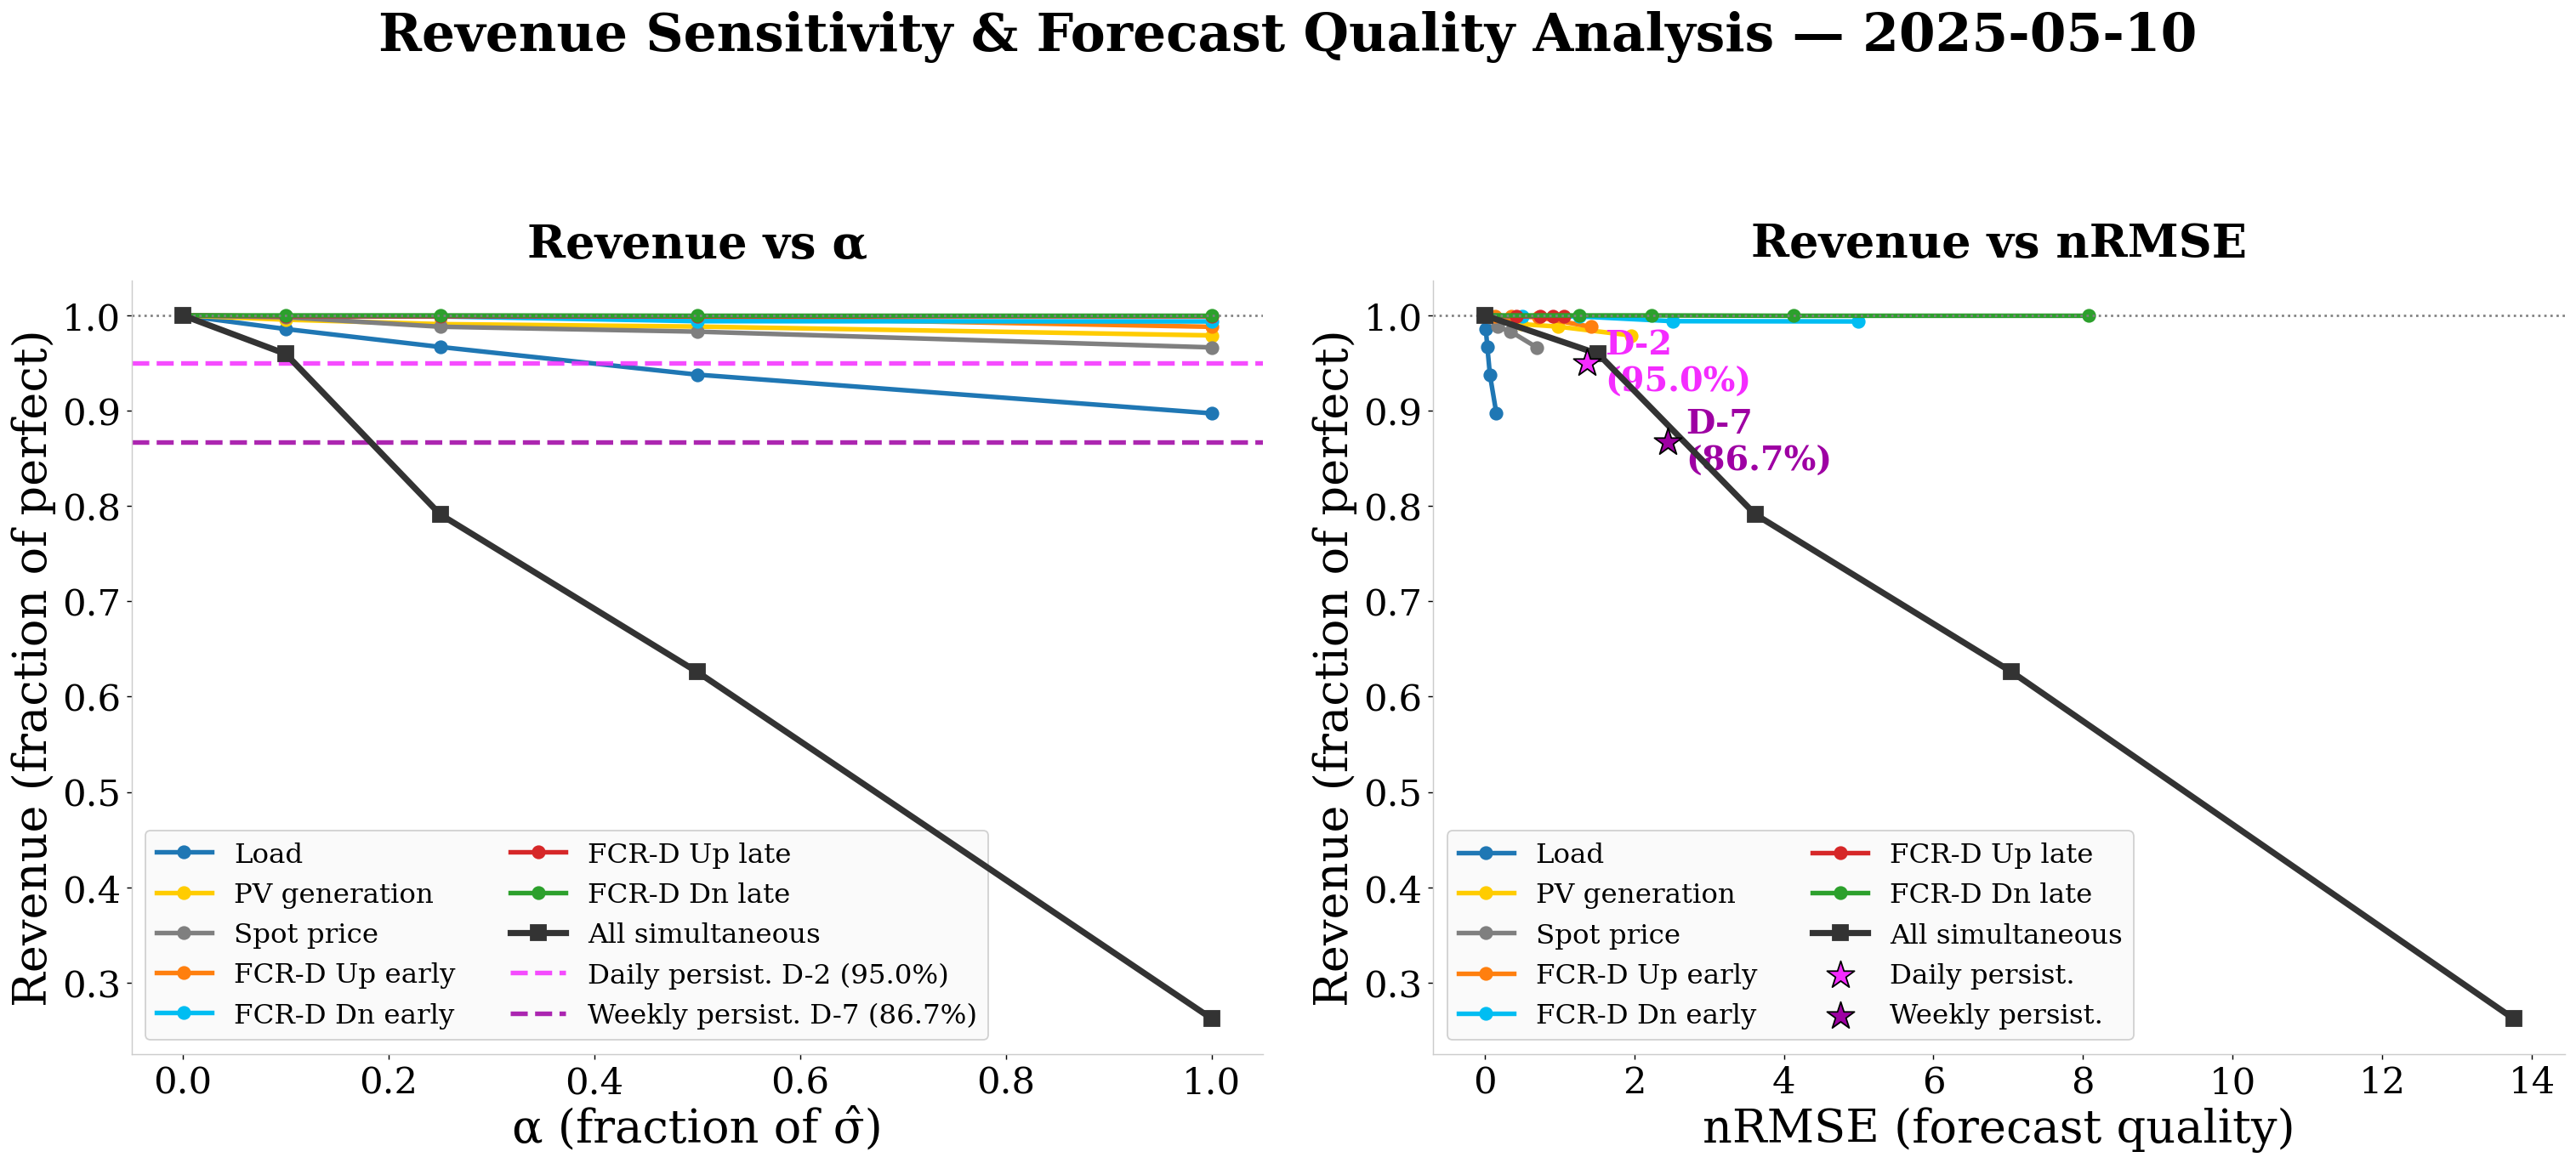

In [90]:

import numpy as np
import matplotlib.pyplot as plt

# ── Global Font Settings (Uniformly Scaled to 30) ────────────────────────────
plt.rcParams.update({
    'font.size': 30,
    'axes.labelsize': 30,
    'axes.titlesize': 30,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'legend.fontsize': 18,     # Scaled cleanly for 2-column legibility
    'figure.titlesize': 34
})

# ── Color Palette Style Mapping (Expanded for Line Differentiation) ──────────
C_PV            = '#FFCC00'   # Vibrant Yellow
C_FCRD_UP_EARLY = '#FF7F0E'   # Safety Orange
C_FCRD_UP_LATE  = '#D62728'   # Deep Red

C_LOAD          = '#1F77B4'   # Royal Blue
C_FCRD_DN_EARLY = '#00BDF2'   # Cyan / Light Blue
C_FCRD_DN_LATE  = '#2CA02C'   # Forest Green

C_SPOT          = '#7F7F7F'   # Neutral Grey
C_DAILY         = '#F42CFF'   # Bright Magenta (Daily Persistence)
C_WEEKLY        = '#9E00A3'   # Deep Dark Magenta (Weekly Persistence)

COLORS = {
    'load':          C_LOAD,
    'pv':            C_PV,
    'spot':          C_SPOT,
    'fcrd_up_early': C_FCRD_UP_EARLY,
    'fcrd_dn_early': C_FCRD_DN_EARLY,
    'fcrd_up_late':  C_FCRD_UP_LATE,
    'fcrd_dn_late':  C_FCRD_DN_LATE,
}

# ── Setup Figure (Expanded Canvas Size for Text Breathing Room) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(24, 11))
fig.patch.set_facecolor('white')

# Simplified headline
fig.suptitle(f'Revenue Sensitivity & Forecast Quality Analysis — {TEST_DATE}', fontweight='bold', y=0.98)

# Mean equivalent alpha positions
alpha_eq_d7 = np.nanmean([v['d7'] for v in pers_equiv_alpha.values()])

# ── Plot 1: Revenue vs α ─────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('white')

for var in ALL_VAR_KEYS:
    d = df_oaat[var]
    ax.plot(d['alpha'], d['rev_norm'], marker='o', lw=3, ms=8,
            color=COLORS[var], label=VAR_LABELS[var])
ax.plot(df_all['alpha'], df_all['rev_norm'], marker='s', lw=4, ms=10,
        color='#333333', label='All simultaneous', zorder=10)

# Horizontal lines for persistence revenue (Shades of Magenta)
ax.axhline(rev_daily,  color=C_DAILY,  ls='--', lw=3, alpha=0.85,
           label=f'Daily persist. D-2 ({rev_daily:.1%})')
ax.axhline(rev_weekly, color=C_WEEKLY, ls='--', lw=3, alpha=0.85,
           label=f'Weekly persist. D-7 ({rev_weekly:.1%})')

ax.axhline(1.0, color='gray', ls=':', lw=1.5)
ax.set_xlabel('α (fraction of σ̂)')
ax.set_ylabel('Revenue (fraction of perfect)')
ax.set_title('Revenue vs α', fontweight='bold', pad=15)
ax.legend(ncol=2, loc='lower left', framealpha=0.9)
ax.grid(False)
ax.spines[['top', 'right']].set_visible(False)

# ── Plot 2: Revenue vs nRMSE ──────────────────────────────────────────────
ax = axes[1]
ax.set_facecolor('white')

for var in ALL_VAR_KEYS:
    data = results_oaat[var]
    nrmse_key = 'load_early' if var == 'load' else ('pv_early' if var == 'pv' else var)
    nrmses    = [r['nrmse'].get(nrmse_key, 0) for r in data]
    ax.plot(nrmses, [r['rev_norm'] for r in data], marker='o', lw=3, ms=8,
            color=COLORS[var], label=VAR_LABELS[var])

nrmses_all = [np.mean(list(r['nrmse'].values())) for r in results_all]
ax.plot(nrmses_all, [r['rev_norm'] for r in results_all],
        marker='s', lw=4, ms=10, color='#333333', label='All simultaneous', zorder=10)

# Persistence stars (Shades of Magenta)
ax.scatter([nrmse_daily_avg],  [rev_daily],  color=C_DAILY,  s=350, marker='*',
           zorder=15, edgecolors='black', lw=1.0, label='Daily persist.')
ax.scatter([nrmse_weekly_avg], [rev_weekly], color=C_WEEKLY, s=350, marker='*',
           zorder=15, edgecolors='black', lw=1.0, label='Weekly persist.')

ax.annotate(f'D-2\n({rev_daily:.1%})', (nrmse_daily_avg, rev_daily),
            textcoords='offset points', xytext=(12, -18), fontsize=22, color=C_DAILY, fontweight='bold')
ax.annotate(f'D-7\n({rev_weekly:.1%})', (nrmse_weekly_avg, rev_weekly),
            textcoords='offset points', xytext=(12, -18), fontsize=22, color=C_WEEKLY, fontweight='bold')

ax.axhline(1.0, color='gray', ls=':', lw=1.5)
ax.set_xlabel('nRMSE (forecast quality)')
ax.set_ylabel('Revenue (fraction of perfect)')
ax.set_title('Revenue vs nRMSE', fontweight='bold', pad=15)
ax.legend(ncol=2, loc='lower left', framealpha=0.9)
ax.grid(False)
ax.spines[['top', 'right']].set_visible(False)

# ── Save & Render Layout ─────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## 19 — Per-variable forecast error comparison

Compare nRMSE and nMAE for each variable across the synthetic noise model (α=1)
and both persistence baselines. This shows which variables are harder to forecast
with simple persistence.

In [78]:
# Run synthetic noise at α=1 for comparison
nc_alpha1 = {k: 1.0 for k in ALL_VAR_KEYS}  # α=1 noise
res_noise_1 = run_pipeline(TEST_DATE, nc_alpha1, RANDOM_SEED)

print(f'Per-variable forecast error comparison — {TEST_DATE}')
print('=' * 95)
print(f'{"Variable":<20s}  {"--- nRMSE ---":^36s}  {"--- nMAE (%) ---":^36s}')
print(f'{"":20s}  {"Noise α=1":>10s} {"Daily":>10s} {"Weekly":>10s}  '
      f'{"Noise α=1":>10s} {"Daily":>10s} {"Weekly":>10s}')
print('-' * 95)

nrmse_keys = ['load_early', 'load_late', 'pv_early', 'pv_late', 'spot',
              'fcrd_up_early', 'fcrd_dn_early', 'fcrd_up_late', 'fcrd_dn_late']

for k in nrmse_keys:
    n1 = res_noise_1['nrmse'].get(k, np.nan)
    nd = res_daily['nrmse'].get(k, np.nan)  if res_daily  else np.nan
    nw = res_weekly['nrmse'].get(k, np.nan) if res_weekly else np.nan
    m1 = res_noise_1['nmae'].get(k, np.nan) * 100
    md = res_daily['nmae'].get(k, np.nan)  * 100 if res_daily  else np.nan
    mw = res_weekly['nmae'].get(k, np.nan) * 100 if res_weekly else np.nan
    print(f'{k:<20s}  {n1:>10.4f} {nd:>10.4f} {nw:>10.4f}  '
          f'{m1:>10.1f} {md:>10.1f} {mw:>10.1f}')

print('-' * 95)
# Averages
for label, res in [('Noise α=1', res_noise_1), ('Daily', res_daily), ('Weekly', res_weekly)]:
    if res is None:
        continue
    avg_nrmse = np.mean(list(res['nrmse'].values()))
    avg_nmae  = np.mean(list(res['nmae'].values())) * 100
    frac = res['total_value'] / baseline_revenue if baseline_revenue else np.nan
    print(f'{label + " (avg)":<20s}  {avg_nrmse:>10.4f} {"":>10s} {"":>10s}  '
          f'{avg_nmae:>10.1f} {"":>10s} {"":>10s}  Rev: {frac:.1%}')


Per-variable forecast error comparison — 2025-05-10
Variable                         --- nRMSE ---                        --- nMAE (%) ---          
                       Noise α=1      Daily     Weekly   Noise α=1      Daily     Weekly
-----------------------------------------------------------------------------------------------
load_early                0.1552     0.1130     0.1491        13.2        8.4       10.9
load_late                 0.1773     0.1130     0.1491        16.3        8.4       10.9
pv_early                  1.2750     3.4314     1.7159        96.7      224.5      108.5
pv_late                   2.5104     3.4314     1.7159       190.0      224.5      108.5
spot                      0.6116     0.4291     0.2648        50.6       33.9       19.4
fcrd_up_early             1.1300     0.6295     0.8428       100.0       44.4       70.7
fcrd_dn_early             1.7126     0.4158     4.8604       137.5       35.1      480.0
fcrd_up_late              2.5243     0.8638

## 20 — Forecast visualization: persistence vs true

Visualize the persistence forecasts alongside true values for the test date.
Shows how daily vs weekly persistence captures (or misses) the actual pattern.

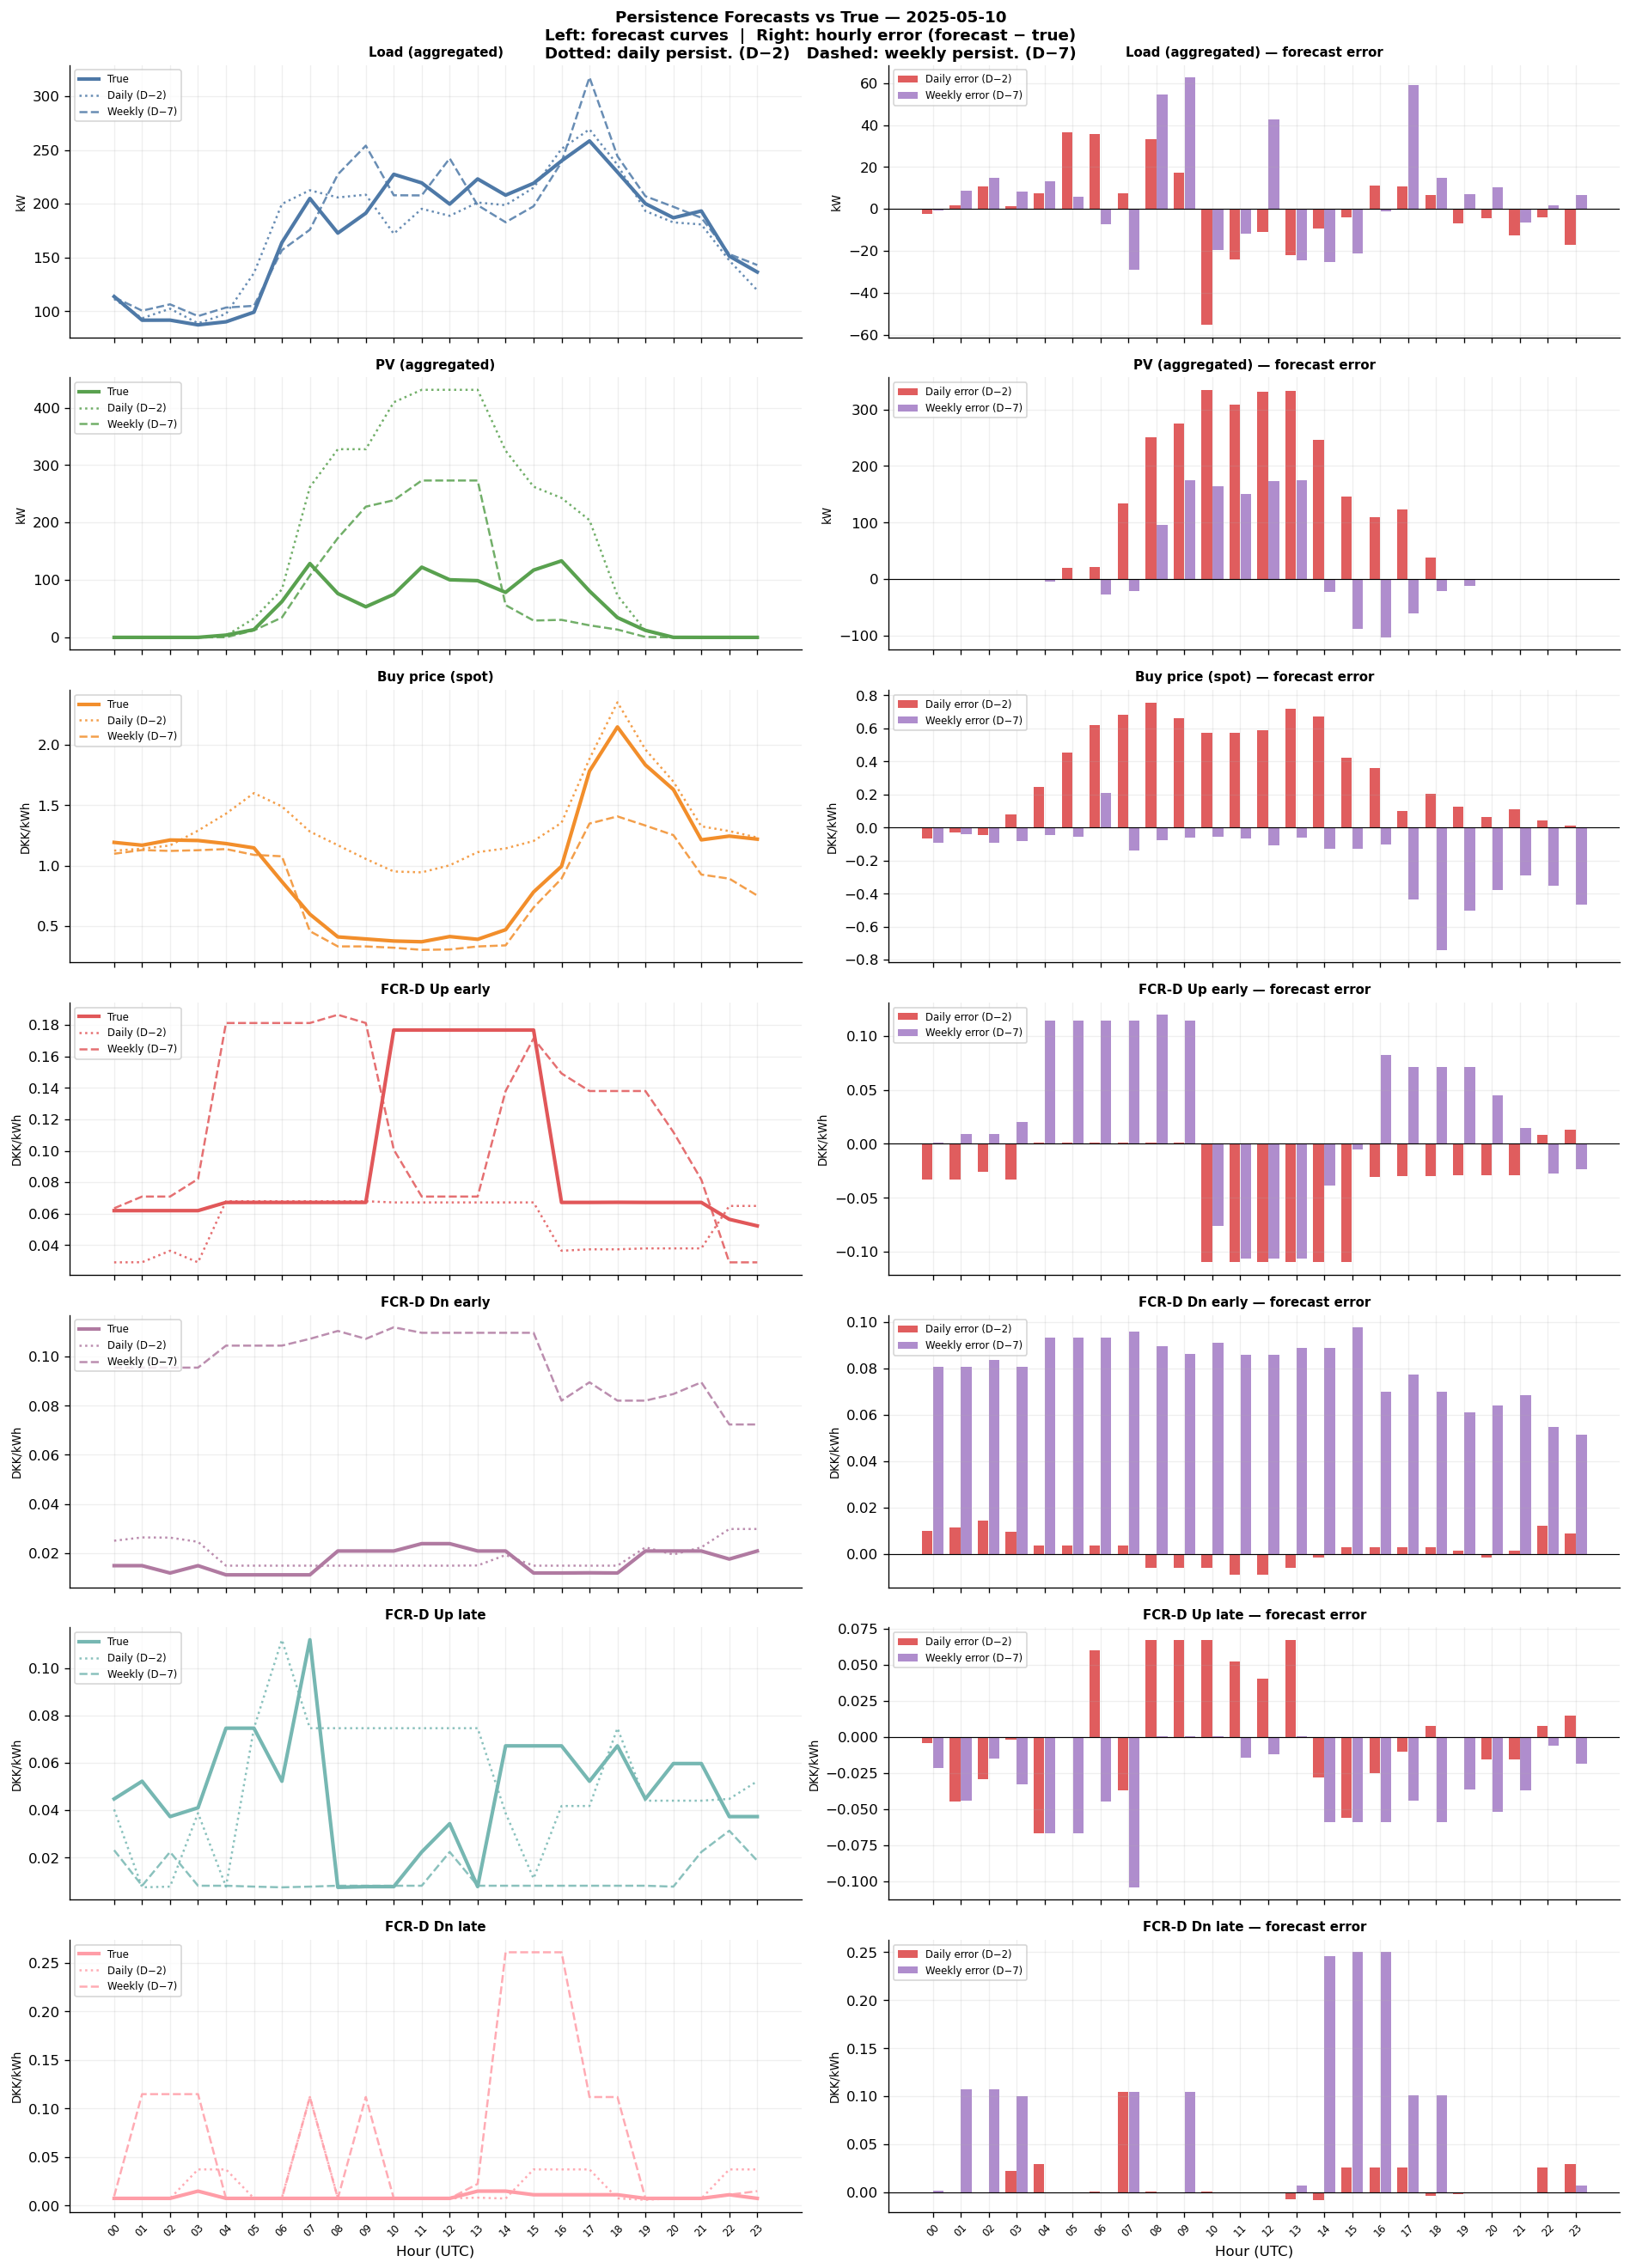

In [79]:
hours = np.arange(24)

# ── helper: pull forecast array from the right sub-dict ─────────────────
def fc_vec(res, sub, key):
    """Safely get a 24-element array from res['forecasts'][sub][key]."""
    return res['forecasts'][sub][key]


# ── variable specs ───────────────────────────────────────────────────────
# (panel title, true_day key, forecast sub-dict, forecast key, colour, unit)
specs = [
    # --- load/PV from aggregated arrays stored in forecasts ---------------
    ('Load (aggregated)',    'D_true_agg',  None,    'D_early_agg',         '#4E79A7', 'kW'),
    ('PV (aggregated)',      'PV_true_agg', None,    'PV_early_agg',        '#59A14F', 'kW'),
    # --- prices from early forecast dict ----------------------------------
    ('Buy price (spot)',     'buy_price',   'early', 'buy_price',           '#F28E2B', 'DKK/kWh'),
    ('FCR-D Up early',       'fcrd_up_early','early','fcrd_up_price',       '#E15759', 'DKK/kWh'),
    ('FCR-D Dn early',       'fcrd_dn_early','early','fcrd_dn_price',       '#B07AA1', 'DKK/kWh'),
    # --- FCR-D late prices from late forecast dict ------------------------
    ('FCR-D Up late',        'fcrd_up_late', 'late', 'fcrd_up_price_late',  '#76B7B2', 'DKK/kWh'),
    ('FCR-D Dn late',        'fcrd_dn_late', 'late', 'fcrd_dn_price_late',  '#FF9DA7', 'DKK/kWh'),
]

n_specs = len(specs)
fig, axes = plt.subplots(n_specs, 2, figsize=(16, 3.2 * n_specs), sharex=True)
fig.suptitle(
    f'Persistence Forecasts vs True — {TEST_DATE}\n'
    f'Left: forecast curves  |  Right: hourly error (forecast − true)\n'
    f'Dotted: daily persist. (D−2)   Dashed: weekly persist. (D−7)',
    fontsize=11, fontweight='bold',
)

for row, (title, true_key, sub, fc_key, color, unit) in enumerate(specs):

    # ── get true values ──────────────────────────────────────────────────
    if sub is None:
        # aggregated load/PV stored directly in forecasts dict
        true_vals   = res_daily['forecasts'][true_key]
        daily_vals  = res_daily['forecasts'][fc_key]
        weekly_vals = res_weekly['forecasts'][fc_key] if res_weekly else None
    else:
        true_vals   = res_daily['forecasts']['true'][true_key]
        daily_vals  = res_daily['forecasts'][sub][fc_key]
        weekly_vals = res_weekly['forecasts'][sub][fc_key] if res_weekly else None

    # ── left panel: forecast curves ──────────────────────────────────────
    ax = axes[row, 0]
    ax.plot(hours, true_vals,  color=color, lw=2.5, label='True')
    ax.plot(hours, daily_vals, color=color, lw=1.5, ls=':',  alpha=0.85, label='Daily (D−2)')
    if weekly_vals is not None:
        ax.plot(hours, weekly_vals, color=color, lw=1.5, ls='--', alpha=0.85, label='Weekly (D−7)')
    ax.set_ylabel(unit, fontsize=8)
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

    # ── right panel: error bars ───────────────────────────────────────────
    ax = axes[row, 1]
    ax.bar(hours - 0.2, daily_vals - true_vals,  0.38,
           color='#D62728', alpha=0.75, label='Daily error (D−2)')
    if weekly_vals is not None:
        ax.bar(hours + 0.2, weekly_vals - true_vals, 0.38,
               color='#9467BD', alpha=0.75, label='Weekly error (D−7)')
    ax.axhline(0, color='black', lw=0.7)
    ax.set_ylabel(unit, fontsize=8)
    ax.set_title(f'{title} — forecast error', fontweight='bold', fontsize=9)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

for ax in axes[-1]:
    ax.set_xticks(range(24))
    ax.set_xticklabels([f'{hh:02d}' for hh in range(24)], rotation=45, fontsize=7)
    ax.set_xlabel('Hour (UTC)')

plt.tight_layout()
plt.show()


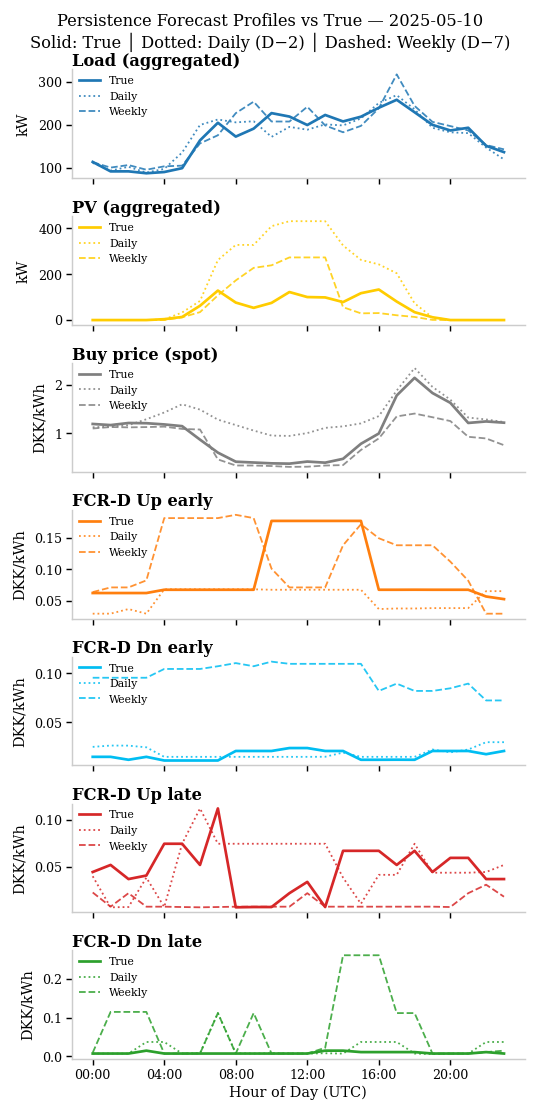

In [96]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.arange(24)

# ── Helper: pull forecast array from the right sub-dict ─────────────────
def fc_vec(res, sub, key):
    """Safely get a 24-element array from res['forecasts'][sub][key]."""
    return res['forecasts'][sub][key]

# ── Variable Specs with Updated Color Palette ─────────────────────────────
specs = [
    ('Load (aggregated)',    'D_true_agg',  None,    'D_early_agg',         '#1F77B4', 'kW'),
    ('PV (aggregated)',      'PV_true_agg', None,    'PV_early_agg',        '#FFCC00', 'kW'),
    ('Buy price (spot)',     'buy_price',   'early', 'buy_price',           '#7F7F7F', 'DKK/kWh'),
    ('FCR-D Up early',       'fcrd_up_early','early','fcrd_up_price',       '#FF7F0E', 'DKK/kWh'),
    ('FCR-D Dn early',       'fcrd_dn_early','early','fcrd_dn_price',       '#00BDF2', 'DKK/kWh'),
    ('FCR-D Up late',        'fcrd_up_late', 'late', 'fcrd_up_price_late',  '#D62728', 'DKK/kWh'),
    ('FCR-D Dn late',        'fcrd_dn_late', 'late', 'fcrd_dn_price_late',  '#2CA02C', 'DKK/kWh'),
]

n_specs = len(specs)

# ── Cohesive Typography Rules (Strictly No Bold Anywhere) ────────────────────
FONT_TITLE  = 9
FONT_LABEL  = 8
FONT_TICK   = 7
FONT_LEGEND = 6

# ── Setup Figure (Width increased to 4.0 to stretch across the column) ───────
fig, axes = plt.subplots(n_specs, 1, figsize=(4.0, 1.25 * n_specs), sharex=True)
fig.patch.set_facecolor('white')

# Main headline unbolded per your request
fig.suptitle(
    f'Persistence Forecast Profiles vs True — {TEST_DATE}\n'
    f'Solid: True │ Dotted: Daily (D−2) │ Dashed: Weekly (D−7)',
    fontsize=FONT_TITLE, y=0.98
)

for row, (title, true_key, sub, fc_key, color, unit) in enumerate(specs):
    ax = axes[row]
    ax.set_facecolor('white')

    # ── Get true and forecast values ─────────────────────────────────────────
    if sub is None:
        true_vals   = res_daily['forecasts'][true_key]
        daily_vals  = res_daily['forecasts'][fc_key]
        weekly_vals = res_weekly['forecasts'][fc_key] if res_weekly else None
    else:
        true_vals   = res_daily['forecasts']['true'][true_key]
        daily_vals  = res_daily['forecasts'][sub][fc_key]
        weekly_vals = res_weekly['forecasts'][sub][fc_key] if res_weekly else None

    # ── Plot Curves ──────────────────────────────────────────────────────────
    ax.plot(hours, true_vals,  color=color, lw=1.5, label='True', zorder=4)
    ax.plot(hours, daily_vals, color=color, lw=1.0, ls=':',  alpha=0.85, label='Daily', zorder=3)
    if weekly_vals is not None:
        ax.plot(hours, weekly_vals, color=color, lw=1.0, ls='--', alpha=0.85, label='Weekly', zorder=2)
    
    # ── Text Formatting (No Bold) ────────────────────────────────────────────
    ax.set_ylabel(unit, fontsize=FONT_LABEL)
    ax.set_title(title, fontsize=FONT_TITLE, loc='left', pad=2)
    ax.legend(fontsize=FONT_LEGEND, loc='upper left', frameon=False, borderpad=0.1)
    
    ax.grid(False)
    ax.tick_params(axis='y', labelsize=FONT_TICK, pad=2)
    ax.spines[['top', 'right']].set_visible(False)

# ── X-Axis Shared Timeline Configuration ─────────────────────────────────────
ax = axes[-1]
tick_hours = range(0, 24, 4)
ax.set_xticks(tick_hours)
ax.set_xticklabels([f'{hh:02d}:00' for hh in tick_hours], rotation=0, fontsize=FONT_TICK)
ax.set_xlabel('Hour of Day (UTC)', fontsize=FONT_LABEL, labelpad=2)
ax.tick_params(axis='x', labelsize=FONT_TICK, pad=2)

# ── Aggressive Margin Reduction (Maximizes horizontal data usage) ────────────
fig.subplots_adjust(
    top=0.93,       
    bottom=0.06,    
    left=0.12,      # Reduced margin pushes plots further to the left edge
    right=0.99,     # Stretches plots right up to the literal edge 
    hspace=0.35     
)

plt.show()

## 21 — Interpretation

**Fill in after running:**

1. **Where does persistence land on the α scale?** Does daily persistence achieve
   revenue comparable to α≈1 in the noise model, or does it differ?

2. **Daily vs weekly**: Which is better? Is weekly persistence a reasonable fallback
   when very recent data is unavailable?

3. **Variable-level errors**: For which variables does persistence produce larger
   or smaller errors than the synthetic noise model? (e.g. PV may be worse in
   persistence if weather changes day-to-day, but prices may be more stable)

4. **Implications for ML forecasting**: Any ML model that beats daily persistence
   will capture revenue above the daily persistence line. The gap between
   persistence and perfect foresight is the maximum revenue upside from
   better forecasting.

5. **Noise model validity**: Does the synthetic Gaussian random walk noise model
   produce a similar revenue outcome as real persistence? If so, the α scale
   is well-calibrated; if not, the noise model may over- or under-estimate
   the difficulty of real forecasting.